In [1]:
# Configure parent directory that contains the 'training output' folder
import os

dir_parent = "/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3"
print("dir_parent set to:", dir_parent)
assert os.path.isdir(dir_parent), f"Directory does not exist: {dir_parent}"


dir_parent set to: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3


importing config
[ok] 4 videos: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos/training output/training_output_CV4.h5
[ok] 8 videos: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_8videos/training output/training_output_CV8.h5
[skip] 10 videos: no dice metrics in /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/training output/training_output_CV10.h5
Saved figure to: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/trend_4_8_10_videos.png


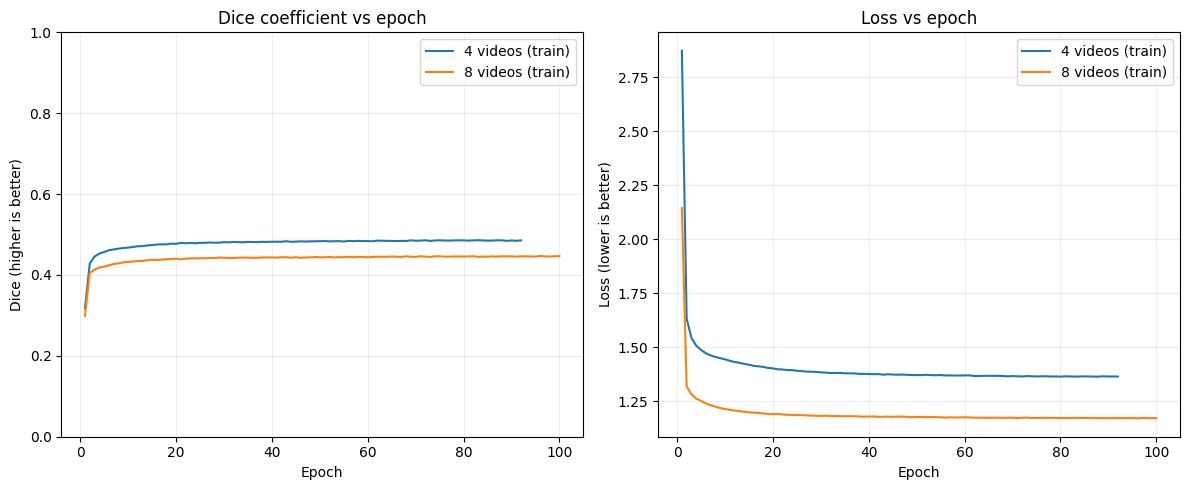

In [2]:
# Re-run overlay with explicit preference for CV counts (4, 8, 10)
import os, sys, glob, h5py
import numpy as np
import matplotlib.pyplot as plt

repo_root = "/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from suns import config as cfg

nb_base = os.path.dirname(os.path.dirname(os.getcwd()))

def parent_for(set_key: str):
    base = cfg.DATAFOLDER_SETS.get(set_key)
    out = cfg.OUTPUT_FOLDER.get(set_key)
    if out is None:
        return None
    candidates = []
    if base is not None:
        candidates.append(os.path.join(base, out))
    candidates.append(os.path.join(nb_base, out))
    for p in candidates:
        if p and os.path.isdir(p):
            return p
    return candidates[0] if candidates else None

groups = {
    '4 videos': parent_for('line3_4videos'),
    '8 videos': parent_for('line3_8videos'),
    '10 videos': parent_for('line3_dataset'),
}
expected_cv = {'4 videos': 4, '8 videos': 8, '10 videos': 10}

curves = {}
for name, parent in groups.items():
    if not parent or not os.path.isdir(parent):
        print(f"[skip] {name}: parent folder missing -> {parent}")
        continue
    train_dir = os.path.join(parent, 'training output')
    if not os.path.isdir(train_dir):
        print(f"[skip] {name}: 'training output' missing in {parent}")
        continue

    pref = os.path.join(train_dir, f"training_output_CV{expected_cv[name]}.h5")
    if os.path.isfile(pref):
        h5_path = pref
    else:
        cand = glob.glob(os.path.join(train_dir, 'training_output_CV*.h5'))
        if not cand:
            cand = glob.glob(os.path.join(train_dir, '*.h5'))
        if not cand:
            print(f"[skip] {name}: no .h5 in {train_dir}")
            continue
        h5_path = max(cand, key=lambda p: os.path.getmtime(p))

    with h5py.File(h5_path, 'r') as f:
        val_dice_loss = np.array(f['val_dice_loss']) if 'val_dice_loss' in f else None
        val_loss = np.array(f['val_loss']) if 'val_loss' in f else None
        dice_loss = np.array(f['dice_loss']) if 'dice_loss' in f else None
        loss = np.array(f['loss']) if 'loss' in f else None

    if val_dice_loss is not None and val_dice_loss.size:
        dice = 1.0 - val_dice_loss
        label = f"{name} (val)"
    elif dice_loss is not None and dice_loss.size:
        dice = 1.0 - dice_loss
        label = f"{name} (train)"
    else:
        print(f"[skip] {name}: no dice metrics in {h5_path}")
        continue

    curves[name] = {'label': label, 'dice': dice, 'loss': val_loss if (val_loss is not None and val_loss.size) else loss, 'src': h5_path}
    print(f"[ok] {name}: {h5_path}")

if not curves:
    print('No curves to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for name, dat in curves.items():
        y = dat['dice']
        axes[0].plot(np.arange(1, len(y)+1), y, label=dat['label'])
    axes[0].set_title('Dice coefficient vs epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Dice (higher is better)')
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, alpha=0.2)
    axes[0].legend()

    any_loss = False
    for name, dat in curves.items():
        if dat['loss'] is not None and len(dat['loss']):
            y = dat['loss']
            axes[1].plot(np.arange(1, len(y)+1), y, label=dat['label'].replace('Dice', 'Loss'))
            any_loss = True
    axes[1].set_title('Loss vs epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss (lower is better)')
    axes[1].grid(True, alpha=0.2)
    if any_loss:
        axes[1].legend()

    fig.tight_layout()
    out_dir = parent_for('line3_dataset') or os.getcwd()
    out_path = os.path.join(out_dir, 'trend_4_8_10_videos.png')
    plt.savefig(out_path, dpi=200)
    print('Saved figure to:', out_path)
    plt.show()


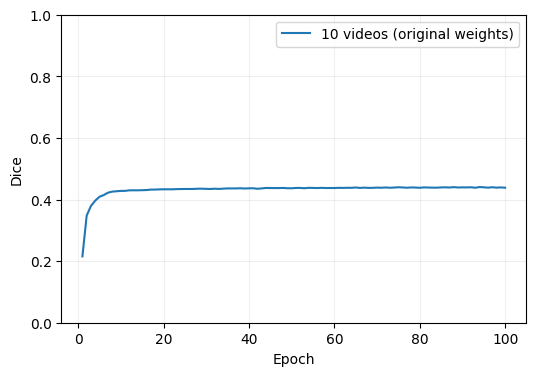

In [5]:
import h5py, numpy as np, matplotlib.pyplot as plt

p = "/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_original_weights/training output/training_output_CV10.h5"

with h5py.File(p, "r") as f:
    val_dice_loss = np.array(f["val_dice_loss"]) if "val_dice_loss" in f else None
    dice_loss = np.array(f["dice_loss"]) if "dice_loss" in f else None
    val_loss = np.array(f["val_loss"]) if "val_loss" in f else None
    loss = np.array(f["loss"]) if "loss" in f else None

dice = 1 - (val_dice_loss if val_dice_loss is not None else dice_loss)
epochs = np.arange(1, len(dice) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, dice, label="10 videos (original weights)")
plt.ylim(0, 1); plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.grid(alpha=0.2); plt.legend()
plt.show()

[ok] 4 videos: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos/training output/training_output_CV4.h5
[ok] 8 videos: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_8videos/training output/training_output_CV8.h5
[ok] 10 videos: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_original_weights/training output/training_output_CV10.h5


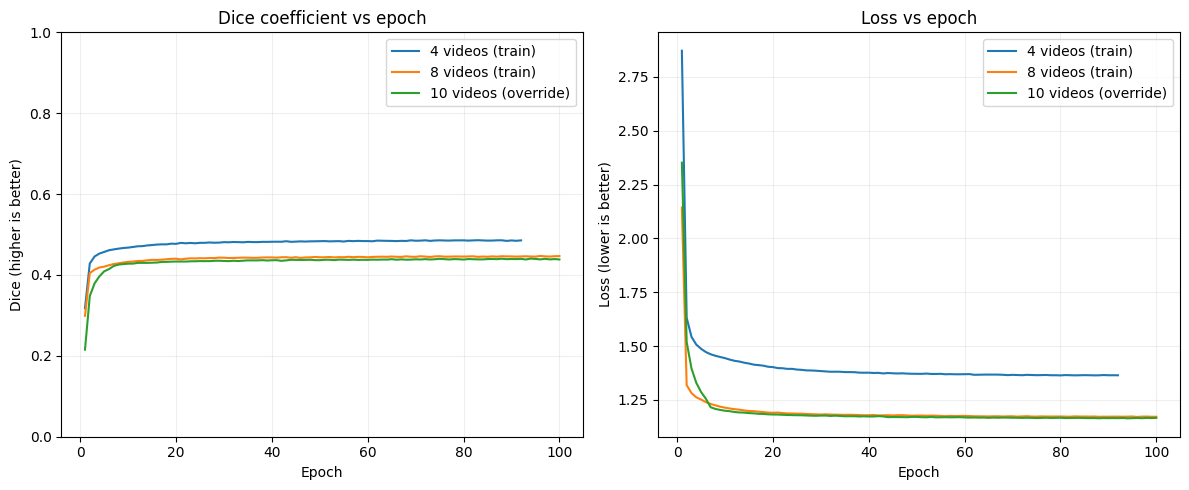

In [6]:
# Overlay with explicit CV10 override from output_original_weights
import os, sys, glob, h5py
import numpy as np
import matplotlib.pyplot as plt

repo_root = "/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from suns import config as cfg

nb_base = os.path.dirname(os.path.dirname(os.getcwd()))

def parent_for(set_key: str):
    base = cfg.DATAFOLDER_SETS.get(set_key)
    out = cfg.OUTPUT_FOLDER.get(set_key)
    if out is None:
        return None
    candidates = []
    if base is not None:
        candidates.append(os.path.join(base, out))
    candidates.append(os.path.join(nb_base, out))
    for p in candidates:
        if p and os.path.isdir(p):
            return p
    return candidates[0] if candidates else None

# Manual override for the 10-video file
cv10_override = "/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_original_weights/training output/training_output_CV10.h5"

# Parents for 4 and 8 videos
parents = {
    '4 videos': parent_for('line3_4videos'),
    '8 videos': parent_for('line3_8videos'),
}

curves = {}

# Load 4 and 8 videos from their latest or expected CV files
expected_cv = {'4 videos': 4, '8 videos': 8}
for name, parent in parents.items():
    if not parent or not os.path.isdir(parent):
        print(f"[skip] {name}: parent folder missing -> {parent}")
        continue
    train_dir = os.path.join(parent, 'training output')
    if not os.path.isdir(train_dir):
        print(f"[skip] {name}: 'training output' missing in {parent}")
        continue
    pref = os.path.join(train_dir, f"training_output_CV{expected_cv[name]}.h5")
    if os.path.isfile(pref):
        h5_path = pref
    else:
        cand = glob.glob(os.path.join(train_dir, 'training_output_CV*.h5')) or glob.glob(os.path.join(train_dir, '*.h5'))
        if not cand:
            print(f"[skip] {name}: no .h5 in {train_dir}")
            continue
        h5_path = max(cand, key=lambda p: os.path.getmtime(p))

    with h5py.File(h5_path, 'r') as f:
        val_dice_loss = np.array(f['val_dice_loss']) if 'val_dice_loss' in f else None
        val_loss = np.array(f['val_loss']) if 'val_loss' in f else None
        dice_loss = np.array(f['dice_loss']) if 'dice_loss' in f else None
        loss = np.array(f['loss']) if 'loss' in f else None
    dice = (1.0 - val_dice_loss) if (val_dice_loss is not None and val_dice_loss.size) else ((1.0 - dice_loss) if (dice_loss is not None and dice_loss.size) else None)
    if dice is None:
        print(f"[skip] {name}: no dice metrics in {h5_path}")
        continue
    curves[name] = {'label': f"{name} (val)" if val_dice_loss is not None else f"{name} (train)", 'dice': dice, 'loss': val_loss if (val_loss is not None and val_loss.size) else loss}
    print(f"[ok] {name}: {h5_path}")

# Load explicit 10 videos override
if os.path.isfile(cv10_override):
    with h5py.File(cv10_override, 'r') as f:
        val_dice_loss = np.array(f['val_dice_loss']) if 'val_dice_loss' in f else None
        val_loss = np.array(f['val_loss']) if 'val_loss' in f else None
        dice_loss = np.array(f['dice_loss']) if 'dice_loss' in f else None
        loss = np.array(f['loss']) if 'loss' in f else None
    dice = (1.0 - val_dice_loss) if (val_dice_loss is not None and val_dice_loss.size) else ((1.0 - dice_loss) if (dice_loss is not None and dice_loss.size) else None)
    if dice is not None:
        curves['10 videos'] = {'label': '10 videos (override)', 'dice': dice, 'loss': val_loss if (val_loss is not None and val_loss.size) else loss}
        print('[ok] 10 videos:', cv10_override)
    else:
        print('[skip] 10 videos: no dice metrics in override file')
else:
    print('[skip] 10 videos: override file not found ->', cv10_override)

# Plot
if not curves:
    print('No curves to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for name, dat in curves.items():
        y = dat['dice']
        axes[0].plot(np.arange(1, len(y)+1), y, label=dat['label'])
    axes[0].set_title('Dice coefficient vs epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Dice (higher is better)')
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, alpha=0.2)
    axes[0].legend()

    any_loss = False
    for name, dat in curves.items():
        if dat['loss'] is not None and len(dat['loss']):
            y = dat['loss']
            axes[1].plot(np.arange(1, len(y)+1), y, label=dat['label'].replace('Dice', 'Loss'))
            any_loss = True
    axes[1].set_title('Loss vs epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss (lower is better)')
    axes[1].grid(True, alpha=0.2)
    if any_loss:
        axes[1].legend()

    fig.tight_layout()
    plt.show()


# Line3 dataset - Analysis

This notebook loads mouse7 data, 
- plots max projection with GT and predicted masks, 
- visualizes ROI area distributions,
- compute and visualize ROIs shape 



In [13]:
# --- Imports and configuration ---
import os, sys, glob, re
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.sparse import csc_matrix
import importlib

# Prefer the git repo; fall back to legacy path. Pick the config that has our set
CANDIDATE_ROOTS = [
    '/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS'
]
TARGET_SET = 'line3_4videos'
for _root in CANDIDATE_ROOTS:
    if _root not in sys.path:
        sys.path.insert(0, _root)
    try:
        from suns import config as suns_config
        importlib.reload(suns_config)
        if TARGET_SET in suns_config.EXP_ID_SETS:
            break
    except Exception:
        continue

from suns.PreProcessing.preprocessing_functions import find_dataset

print('Using config at:', suns_config.__file__)
print('Available sets:', list(suns_config.EXP_ID_SETS.keys()))

# Dataset selection
active_set = TARGET_SET
exp_id = 'mouse7'

# Paths for this dataset
list_Exp_ID = suns_config.EXP_ID_SETS[active_set]
dir_video = suns_config.DATAFOLDER_SETS[active_set]

# Output folder selection (override-capable)
# Default name from config; allow selection among line3 variants
OUTPUT_FOLDER_NAME = suns_config.OUTPUT_FOLDER[active_set]
line3_output_variant = 'output_line3_4videos'  # options: 'output_line3', 'output_line3_scaled', 'output_line3_4videos', 'output_line3_8videos'

# Environment overrides
OUTPUT_FOLDER_ENV = os.environ.get('SUNS_OUTPUT_FOLDER', None)
OUTPUT_PARENT_OVERRIDE = os.environ.get('SUNS_OUTPUT_PARENT', None)
LINE3_VARIANT_ENV = os.environ.get('SUNS_LINE3_OUTPUT', None)

# Resolve folder name
if OUTPUT_FOLDER_ENV:
    OUTPUT_FOLDER_NAME = OUTPUT_FOLDER_ENV
elif active_set in {'line3_dataset', 'line3_scaled', 'line3_4videos', 'line3_8videos'}:
    choice = LINE3_VARIANT_ENV or line3_output_variant
    allowed = {'output_line3', 'output_line3_scaled', 'output_line3_4videos', 'output_line3_8videos'}
    if choice not in allowed:
        raise ValueError(f"Invalid line3 output choice: {choice}. Allowed: {sorted(allowed)}")
    OUTPUT_FOLDER_NAME = choice

# Resolve parent directory
if OUTPUT_PARENT_OVERRIDE:
    dir_parent = OUTPUT_PARENT_OVERRIDE
else:
    dir_parent = os.path.join(dir_video, OUTPUT_FOLDER_NAME)

dir_net_in = os.path.join(dir_parent, 'network_input')
weights_path = os.path.join(dir_parent, 'Weights')
dir_output = os.path.join(dir_parent, 'output_masks')

print('dir_video:', dir_video)
print('dir_parent:', dir_parent)
print('dir_output:', dir_output)


importing config
Using config at: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/suns/config.py
Available sets: ['data', 'line3_dataset', 'line3_scaled', 'line3_4videos', 'line3_8videos', 'only_mouse7', 'mouse7_new', 'mouse7_suite2pGT', '4video_mouse7', '4videos_mouse7', '8videos_mouse7', '4mouse7_demo_pipeline', '4mouse7_pmap', '4mouse7_custom_params', '4mouse7_final']
dir_video: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset
dir_parent: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos
dir_output: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos/output_masks


In [14]:
# --- Helper functions ---
from typing import Tuple

def compute_max_projection_from_h5(h5_path: str) -> np.ndarray:
    with h5py.File(h5_path, 'r') as f:
        dset_name = find_dataset(f)
        dset = f[dset_name]
        nframes = dset.shape[0]
        max_img = np.array(dset[0], dtype=np.float32)
        for i in range(1, nframes):
            np.maximum(max_img, dset[i], out=max_img)
    vmin, vmax = float(max_img.min()), float(max_img.max())
    if vmax > vmin:
        max_img = (max_img - vmin) / (vmax - vmin)
    else:
        max_img = np.zeros_like(max_img, dtype=np.float32)
    return max_img


def load_gt_sparse_masks(gt_sparse_path: str, dims: Tuple[int, int]) -> np.ndarray:
    Lx, Ly = dims
    md = loadmat(gt_sparse_path)
    GT = csc_matrix(md['GTMasks_2'])
    pixels = Lx * Ly
    if GT.shape[0] == pixels and GT.shape[1] != pixels:
        GTp = GT
        
    elif GT.shape[1] == pixels and GT.shape[0] != pixels:
        GTp = GT.transpose()
    else:
        GTp = GT
    n_gt = GTp.shape[1]
    masks = np.zeros((n_gt, Lx, Ly), dtype=bool)
    for j in range(n_gt):
        idx = GTp.getcol(j).indices
        masks[j].ravel()[idx] = True
    return masks


def load_pred_masks_from_mat(out_mat_path: str, dims: Tuple[int, int]) -> np.ndarray:
    Lx, Ly = dims
    md = loadmat(out_mat_path)
    m = md.get('Masks')
    if m is None:
        raise RuntimeError("'Masks' not found in output mat")
    m = np.asarray(m)
    if m.ndim != 3:
        raise ValueError(f"Masks must be 3D, got shape {m.shape}")

    # Heuristic: identify which axis is not a spatial dim (Lx or Ly) → that's N
    dims_set = {int(Lx), int(Ly)}
    shape = tuple(int(x) for x in m.shape)
    non_spatial_axes = [ax for ax, sz in enumerate(shape) if sz not in dims_set]

    if len(non_spatial_axes) == 1:
        aN = non_spatial_axes[0]
        other = [ax for ax in range(3) if ax != aN]
        # map Lx/Ly to last two axes in order (Lx, Ly)
        ax_lx = next(ax for ax in other if shape[ax] == Lx)
        ax_ly = next(ax for ax in other if ax != ax_lx)
        masks = np.transpose(m.astype(bool), (aN, ax_lx, ax_ly))
        # ensure (N, Lx, Ly) order; if swapped, fix
        if masks.shape[1:] == (Ly, Lx):
            masks = np.transpose(masks, (0, 2, 1))
    else:
        # Ambiguous (e.g., Lx==Ly==N). Fall back to MATLAB-friendly (Lx, Ly, N) → (N, Lx, Ly)
        masks = np.transpose(m.astype(bool), (2, 0, 1))
        if masks.shape[1:] == (Ly, Lx):
            masks = np.transpose(masks, (0, 2, 1))

    # Final sanity check on spatial dims
    if masks.shape[1:] != (Lx, Ly):
        # try swapping if still mismatched
        if masks.shape[1:] == (Ly, Lx):
            masks = np.transpose(masks, (0, 2, 1))
        else:
            raise ValueError(f"Masks spatial dims {masks.shape[1:]} do not match expected {(Lx, Ly)}")

    return masks


def pad_masks_top_left(masks: np.ndarray, target_dims: Tuple[int, int]) -> np.ndarray:
    """Pad masks (N, Lx_src, Ly_src) into top-left of a (N, Lx_tgt, Ly_tgt) canvas.
    If masks already match target size, returns as-is.
    """
    if masks.ndim != 3:
        raise ValueError('masks must be (N, Lx, Ly)')
    n, Lx_src, Ly_src = masks.shape
    Lx_tgt, Ly_tgt = target_dims
    if (Lx_src, Ly_src) == (Lx_tgt, Ly_tgt):
        return masks
    out = np.zeros((n, Lx_tgt, Ly_tgt), dtype=masks.dtype)
    out[:, :Lx_src, :Ly_src] = masks
    return out


def transform_masks(masks: np.ndarray, rot_k: int = 0, flip_ud: bool = False, flip_lr: bool = False) -> np.ndarray:
    """Apply 90° rotations and flips to masks array (N, Lx, Ly)."""
    if masks.ndim != 3:
        return masks
    out = masks
    rk = rot_k % 4
    if rk:
        out = np.rot90(out, k=rk, axes=(1, 2))
    if flip_ud:
        out = np.flip(out, axis=1)
    if flip_lr:
        out = np.flip(out, axis=2)
    return out


In [15]:
# --- Load data and compute max projection ---
# Prefer the preprocessed network_input for consistency with pipeline
h5_net_in = os.path.join(dir_net_in, f'{exp_id}.h5')
if os.path.exists(h5_net_in):
    with h5py.File(h5_net_in, 'r') as f:
        network_input = np.array(f['network_input'])  # (T, Lx, Ly)
    T, Lx, Ly = network_input.shape
    max_img = network_input.max(axis=0).astype(np.float32)
    vmin, vmax = float(max_img.min()), float(max_img.max())
    if vmax > vmin:
        max_img = (max_img - vmin) / (vmax - vmin)
else:
    # Fallback to raw video
    raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
    assert os.path.exists(raw_h5), f'Missing video: {raw_h5}'
    max_img = compute_max_projection_from_h5(raw_h5)
    Lx, Ly = max_img.shape

# Load masks
gt_sparse = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{exp_id}_sparse.mat')
if os.path.exists(gt_sparse):
    gt_masks = load_gt_sparse_masks(gt_sparse, (Lx, Ly))
else:
    gt_masks = np.zeros((0, Lx, Ly), dtype=bool)

pred_mat = os.path.join(dir_output, f'Output_Masks_{exp_id}.mat')
if os.path.exists(pred_mat):
    pred_masks = load_pred_masks_from_mat(pred_mat, (Lx, Ly))
else:
    pred_masks = np.zeros((0, Lx, Ly), dtype=bool)

n_gt = gt_masks.shape[0]
n_pred = pred_masks.shape[0]
print(f'N_GT={n_gt}, N_pred={n_pred}, shape={Lx}x{Ly}')


N_GT=1104, N_pred=748, shape=256x256


Saved preview to: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos/raw_snr_preview_mouse7.png


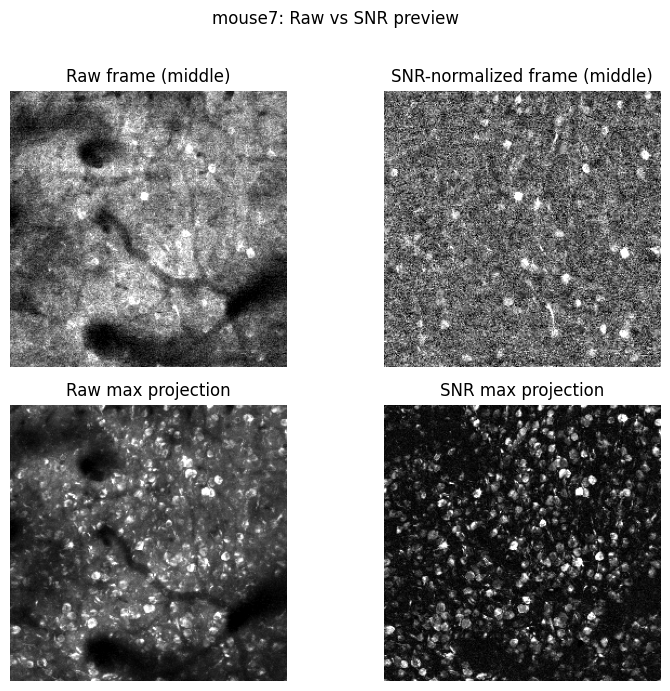

In [16]:
# --- Preview raw video and SNR-normalized video (end of preprocessing) ---
import os, h5py
import numpy as np
import matplotlib.pyplot as plt

# Paths
raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
h5_net_in = os.path.join(dir_net_in, f'{exp_id}.h5')

# Load SNR (network_input) stack if not in memory
if 'network_input' not in globals():
    assert os.path.exists(h5_net_in), f'Missing network_input: {h5_net_in}'
    with h5py.File(h5_net_in, 'r') as f:
        network_input = np.array(f['network_input'])  # (T, Y, X)

# Load raw stack shape and a representative frame without reading entire movie
assert os.path.exists(raw_h5), f'Missing raw video: {raw_h5}'
with h5py.File(raw_h5, 'r') as f:
    dset_name = find_dataset(f)  # helper defined earlier
    dset = f[dset_name]
    T_raw = dset.shape[0]
    # pick a middle frame for preview
    t0 = int(T_raw // 2)
    raw_frame = dset[t0].astype(np.float32)

# SNR frame at same index (clamp if lengths differ)
T_snr = network_input.shape[0]
t1 = min(t0, T_snr - 1)
snr_frame = network_input[t1].astype(np.float32)

# Normalize frames for display using robust percentiles
def normalize_img(img):
    p1, p99 = np.percentile(img, (1, 99))
    if p99 > p1:
        img = (img - p1) / (p99 - p1)
    return np.clip(img, 0, 1)

raw_frame_n = normalize_img(raw_frame)
snr_frame_n = normalize_img(snr_frame)

# Max projections (robust-normalized)
raw_max = normalize_img(compute_max_projection_from_h5(raw_h5))
snr_max = normalize_img(network_input.max(axis=0).astype(np.float32))

# Plot 2x2: raw frame, snr frame, raw max, snr max
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.ravel()

axes[0].imshow(raw_frame_n, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Raw frame (middle)')
axes[0].axis('off')

axes[1].imshow(snr_frame_n, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('SNR-normalized frame (middle)')
axes[1].axis('off')

axes[2].imshow(raw_max, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Raw max projection')
axes[2].axis('off')

axes[3].imshow(snr_max, cmap='gray', vmin=0, vmax=1)
axes[3].set_title('SNR max projection')
axes[3].axis('off')

plt.suptitle(f'{exp_id}: Raw vs SNR preview', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.965])

out_png_preview = os.path.join(dir_parent, f'raw_snr_preview_{exp_id}.png')
plt.savefig(out_png_preview, dpi=200)
print('Saved preview to:', out_png_preview)
plt.show()


In [17]:
# --- Align GT/Pred to network_input grid while keeping network_input max projection ---
# Read raw dims (fast) and rebuild GT accordingly, then pad to (Lx, Ly)
GT_ROT_K = 1 # default; may be overridden by auto-align
GT_FLIPUD = False
GT_FLIPLR = False

PRED_ROT_K = 0 # default; may be overridden by auto-align
PRED_FLIPUD = False
PRED_FLIPLR = False

raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
assert os.path.exists(raw_h5), f'Missing video: {raw_h5}'
with h5py.File(raw_h5, 'r') as f:
    dset_name = find_dataset(f)
    Lx_raw, Ly_raw = f[dset_name].shape[1:3]  # no full read, just shape

# Rebuild GT from raw dims
if os.path.exists(gt_sparse):
    gt_masks_raw = load_gt_sparse_masks(gt_sparse, (Lx_raw, Ly_raw))
else:
    gt_masks_raw = np.zeros((0, Lx_raw, Ly_raw), dtype=bool)

# Target dims = network_input dims if available
if 'network_input' in globals():
    Lx_net, Ly_net = network_input.shape[1:]
    max_img_net = network_input.max(axis=0).astype(np.float32)
    vmin_, vmax_ = float(max_img_net.min()), float(max_img_net.max())
    if vmax_ > vmin_:
        max_img_net = (max_img_net - vmin_) / (vmax_ - vmin_)
else:
    Lx_net, Ly_net = Lx, Ly
    # reuse max_img computed earlier
    max_img_net = max_img.astype(np.float32)

# --- Auto-align by maximizing mean max-projection intensity under masks ---
from itertools import product

def _score_alignment(masks_bool, img_f32):
    if masks_bool.size == 0:
        return -np.inf
    # Reduce 3D stacks (N, Lx, Ly) to a 2D union mask for scoring against 2D max projection
    if masks_bool.ndim == 3:
        union = np.any(masks_bool, axis=0)
    elif masks_bool.ndim == 2:
        union = masks_bool
    else:
        return -np.inf
    area = int(union.sum())
    if area == 0:
        return -np.inf
    return float(img_f32[union].mean())

combos = [(k, u, l) for k in range(4) for u in (False, True) for l in (False, True)]

def _best_transform_for_masks(masks_src, src_dims, tgt_dims, img_tgt):
    best = (-np.inf, 0, False, False, None)
    for rk, fud, flr in combos:
        m_tf = transform_masks(masks_src, rot_k=rk, flip_ud=fud, flip_lr=flr)
        # pad/crop to target dims (top-left pad)
        if m_tf.shape[1:] != tgt_dims:
            m_tf = pad_masks_top_left(m_tf, tgt_dims)
        score = _score_alignment(m_tf, img_tgt)
        if score > best[0]:
            best = (score, rk, fud, flr, m_tf)
    return best  # (score, rk, fud, flr, masks_aligned)

# Choose best transform for GT (from raw -> net)
_, GT_ROT_K, GT_FLIPUD, GT_FLIPLR, gt_masks = _best_transform_for_masks(
    gt_masks_raw, (Lx_raw, Ly_raw), (Lx_net, Ly_net), max_img_net
)

# Choose best transform for Pred (handle either raw-sized or net-sized inputs)
if pred_masks.shape[1:] == (Lx_raw, Ly_raw):
    _, PRED_ROT_K, PRED_FLIPUD, PRED_FLIPLR, pred_masks = _best_transform_for_masks(
        pred_masks, (Lx_raw, Ly_raw), (Lx_net, Ly_net), max_img_net
    )
else:
    _, PRED_ROT_K, PRED_FLIPUD, PRED_FLIPLR, pred_masks = _best_transform_for_masks(
        pred_masks, pred_masks.shape[1:], (Lx_net, Ly_net), max_img_net
    )

# Update counters and dimensions for plotting
Lx, Ly = Lx_net, Ly_net
n_gt = gt_masks.shape[0]
n_pred = pred_masks.shape[0]
print(
    f'Aligned: raw={Lx_raw}x{Ly_raw} -> net_in={Lx}x{Ly}; '
    f'N_GT={n_gt}, N_pred={n_pred}; '
    f'GT(rot={GT_ROT_K},ud={GT_FLIPUD},lr={GT_FLIPLR}), '
    f'PRED(rot={PRED_ROT_K},ud={PRED_FLIPUD},lr={PRED_FLIPLR})'
)


Aligned: raw=256x256 -> net_in=256x256; N_GT=1104, N_pred=748; GT(rot=1,ud=True,lr=False), PRED(rot=1,ud=True,lr=False)


Saved overlay to: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos/overlay_mouse7.png


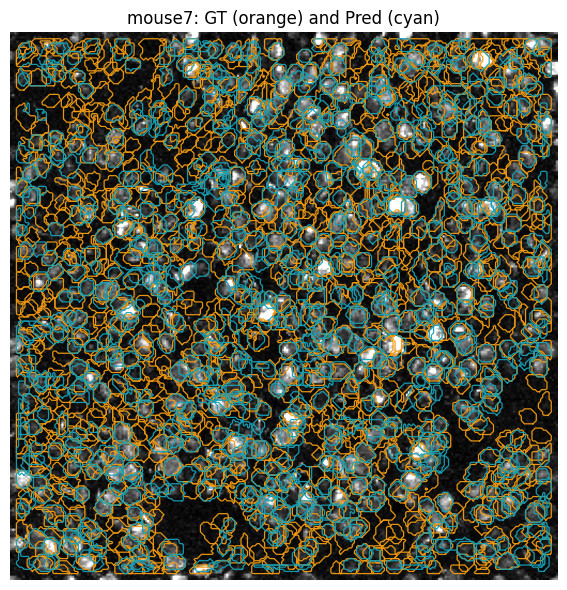

Saved triptych to: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos/overlay_triptych_mouse7.png


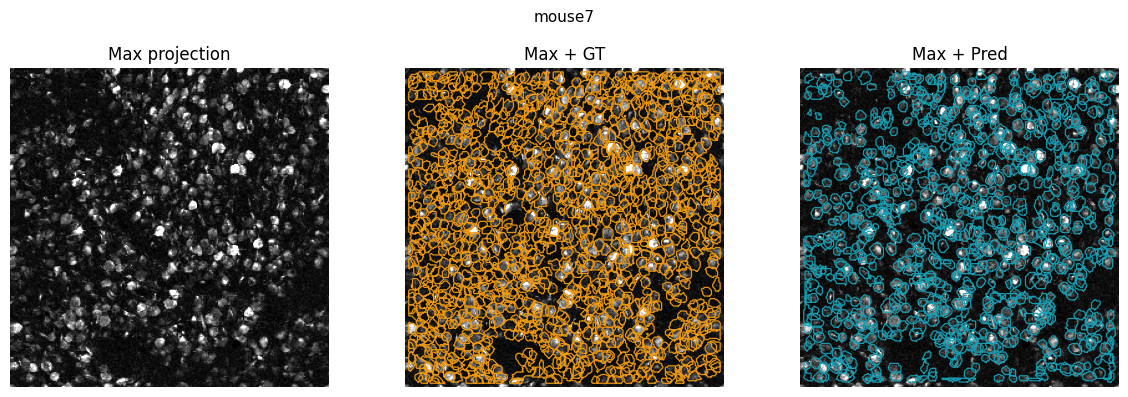

In [18]:
# --- Static overlay (no GUI) of GT & Pred on max projection ---
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure


def plot_overlay_maxproj(max_img, gt_masks, pred_masks, out_path=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    vmin, vmax = np.percentile(max_img, (1, 99))
    ax.imshow(max_img, cmap='gray', vmin=vmin, vmax=vmax)

    # GT in orange
    for i in range(gt_masks.shape[0]):
        m = gt_masks[i]
        if m.any():
            for c in measure.find_contours(m.astype(float), 0.5):
                ax.plot(c[:, 1], c[:, 0], color='#F39C12', lw=0.9, alpha=0.95)

    # Pred in cyan
    for i in range(pred_masks.shape[0]):
        m = pred_masks[i]
        if m.any():
            for c in measure.find_contours(m.astype(float), 0.5):
                ax.plot(c[:, 1], c[:, 0], color='#17A2B8', lw=0.9, alpha=0.95)

    ax.set_title(f"{exp_id}: GT (orange) and Pred (cyan)")
    ax.axis('off')
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200)
        print('Saved overlay to:', out_path)
    plt.show()


def _draw_contours(ax, masks, color, lw=0.9, alpha=0.95):
    for i in range(masks.shape[0]):
        m = masks[i]
        if m.any():
            for c in measure.find_contours(m.astype(float), 0.5):
                ax.plot(c[:, 1], c[:, 0], color=color, lw=lw, alpha=alpha)


def plot_overlay_triptych(max_img, gt_masks, pred_masks, out_path=None):
    vmin, vmax = np.percentile(max_img, (1, 99))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # 1) Max projection only
    axes[0].imshow(max_img, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title('Max projection')
    axes[0].axis('off')

    # 2) Max + GT
    axes[1].imshow(max_img, cmap='gray', vmin=vmin, vmax=vmax)
    _draw_contours(axes[1], gt_masks, color='#F39C12')
    axes[1].set_title('Max + GT')
    axes[1].axis('off')

    # 3) Max + Pred
    axes[2].imshow(max_img, cmap='gray', vmin=vmin, vmax=vmax)
    _draw_contours(axes[2], pred_masks, color='#17A2B8')
    axes[2].set_title('Max + Pred')
    axes[2].axis('off')

    fig.suptitle(exp_id, y=0.98, fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if out_path:
        plt.savefig(out_path, dpi=200)
        print('Saved triptych to:', out_path)
    plt.show()

# Ensure we have a max image
if 'max_img' not in globals():
    if 'network_input' in globals():
        max_img = network_input.max(axis=0).astype(np.float32)
        vmin, vmax = float(max_img.min()), float(max_img.max())
        if vmax > vmin:
            max_img = (max_img - vmin) / (vmax - vmin)
    else:
        raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
        assert os.path.exists(raw_h5), f'Missing video: {raw_h5}'
        max_img = compute_max_projection_from_h5(raw_h5)

# Save next to outputs
out_png = os.path.join(dir_parent, f'overlay_{exp_id}.png')
plot_overlay_maxproj(max_img, gt_masks, pred_masks, out_path=out_png)

# Triptych (1x3) figure
out_png3 = os.path.join(dir_parent, f'overlay_triptych_{exp_id}.png')
plot_overlay_triptych(max_img, gt_masks, pred_masks, out_path=out_png3)



Metrics file: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos/output_masks/Output_Info_All.mat


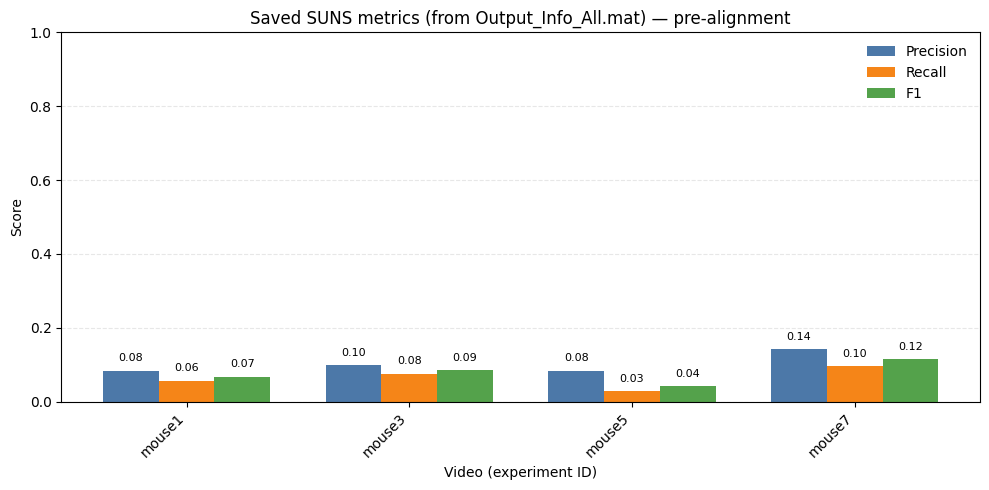

In [19]:
# --- Plot saved metrics from Output_Info_All.mat with video names (pre-alignment results) ---
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import os

info_mat = os.path.join(dir_output, 'Output_Info_All.mat')
print('Metrics file:', info_mat)

if not os.path.exists(info_mat):
    print('Output_Info_All.mat not found. Skipping.')
else:
    md = loadmat(info_mat, squeeze_me=True, struct_as_record=False)
    P = np.asarray(md.get('list_Precision', []), dtype=float).ravel()
    R = np.asarray(md.get('list_Recall', []), dtype=float).ravel()
    F = np.asarray(md.get('list_F1', []), dtype=float).ravel()
    N = max(len(P), len(R), len(F))

    names = list_Exp_ID[:N] if 'list_Exp_ID' in globals() and len(list_Exp_ID) >= N else [str(i) for i in range(N)]

    x = np.arange(N); w = 0.25
    plt.figure(figsize=(max(10, 1.6*N), 5))
    plt.bar(x - w, P, width=w, label='Precision', color='#4C78A8')
    plt.bar(x,      R, width=w, label='Recall',    color='#F58518')
    plt.bar(x + w,  F, width=w, label='F1',        color='#54A24B')
    plt.xticks(x, names, rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.xlabel('Video (experiment ID)')
    plt.ylabel('Score')
    plt.title('Saved SUNS metrics (from Output_Info_All.mat) — pre-alignment')
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.legend(frameon=False)

    # annotate values
    for i in range(N):
        for j, v in enumerate([P[i] if i < len(P) else np.nan,
                               R[i] if i < len(R) else np.nan,
                               F[i] if i < len(F) else np.nan]):
            if np.isfinite(v):
                xpos = x[i] + (j-1)*w
                plt.text(xpos, min(0.98, v + 0.02), f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()



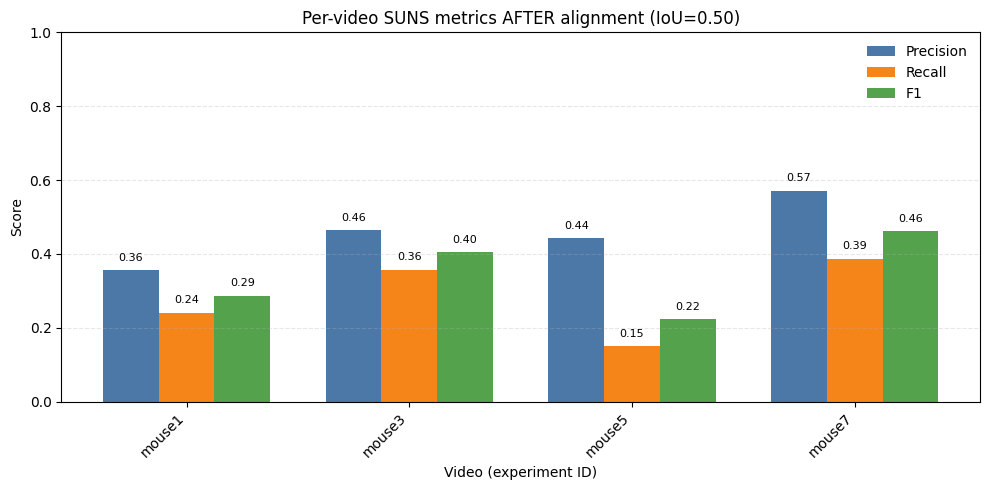

In [20]:
# --- Per-video SUNS metrics AFTER alignment (same style, names on x-axis) ---
from suns.PostProcessing.evaluate import GetPerformance_Jaccard_2
from scipy import sparse
import numpy as np
import matplotlib.pyplot as plt
import os, h5py

# IoU evaluation threshold (match the standard unless you change it)
iou_eval_after = 0.50

exp_ids = list(list_Exp_ID)
P_after, R_after, F_after = [], [], []

for eid in exp_ids:
    # Paths
    raw_h5_e   = os.path.join(dir_video, f'{eid}.h5')
    gt_sparse_e = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{eid}_sparse.mat')
    pred_mat_e  = os.path.join(dir_output, f'Output_Masks_{eid}.mat')

    # Target grid = network_input when available
    h5_net_in_e = os.path.join(dir_net_in, f'{eid}.h5')
    if os.path.exists(h5_net_in_e):
        with h5py.File(h5_net_in_e, 'r') as f:
            net_in_e = np.array(f['network_input'])
        Lx_net_e, Ly_net_e = net_in_e.shape[1:]
        max_img_net_e = net_in_e.max(axis=0).astype(np.float32)
        vmin_, vmax_ = float(max_img_net_e.min()), float(max_img_net_e.max())
        if vmax_ > vmin_:
            max_img_net_e = (max_img_net_e - vmin_) / (vmax_ - vmin_)
    else:
        with h5py.File(raw_h5_e, 'r') as f:
            dset_name_e = find_dataset(f)
            Lx_net_e, Ly_net_e = f[dset_name_e].shape[1:3]
            max_img_net_e = compute_max_projection_from_h5(raw_h5_e)

    # Raw dims
    with h5py.File(raw_h5_e, 'r') as f:
        dset_name_e = find_dataset(f)
        Lx_raw_e, Ly_raw_e = f[dset_name_e].shape[1:3]

    # Load raw GT / Pred
    gt_raw_e = load_gt_sparse_masks(gt_sparse_e, (Lx_raw_e, Ly_raw_e)) if os.path.exists(gt_sparse_e) else np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)
    pred_e   = load_pred_masks_from_mat(pred_mat_e, (Lx_raw_e, Ly_raw_e)) if os.path.exists(pred_mat_e) else np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)

    # Align to target grid using the same helper as earlier in the notebook
    _, _, _, _, gt_aligned_e = _best_transform_for_masks(gt_raw_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
    if pred_e.shape[1:] == (Lx_raw_e, Ly_raw_e):
        _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
    else:
        _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, pred_e.shape[1:], (Lx_net_e, Ly_net_e), max_img_net_e)

    # SUNS evaluation at IoU threshold
    GT_csr  = sparse.csr_matrix(gt_aligned_e.reshape(gt_aligned_e.shape[0], -1).astype(np.uint32))
    PR_csr  = sparse.csr_matrix(pred_aligned_e.reshape(pred_aligned_e.shape[0], -1).astype(np.uint32))
    ThreshJ = 1.0 - float(iou_eval_after)
    R, P, F1 = GetPerformance_Jaccard_2(GT_csr, PR_csr, ThreshJ=ThreshJ)
    P_after.append(float(P)); R_after.append(float(R)); F_after.append(float(F1))

# Plot in same grouped style
N = len(exp_ids)
x = np.arange(N); w = 0.25
plt.figure(figsize=(max(10, 1.6*N), 5))
plt.bar(x - w, P_after, width=w, label='Precision', color='#4C78A8')
plt.bar(x,      R_after, width=w, label='Recall',    color='#F58518')
plt.bar(x + w,  F_after, width=w, label='F1',        color='#54A24B')
plt.xticks(x, exp_ids, rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.xlabel('Video (experiment ID)')
plt.ylabel('Score')
plt.title(f'Per-video SUNS metrics AFTER alignment (IoU={iou_eval_after:.2f})')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=False)

# annotate values
for i in range(N):
    for j, v in enumerate([P_after[i], R_after[i], F_after[i]]):
        xpos = x[i] + (j-1)*w
        plt.text(xpos, min(0.98, v + 0.02), f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()



mouse1: IoU=0.20  P=0.777  R=0.526  F1=0.627
mouse3: IoU=0.20  P=0.789  R=0.607  F1=0.686
mouse5: IoU=0.20  P=0.826  R=0.279  F1=0.418
mouse7: IoU=0.20  P=0.829  R=0.562  F1=0.670


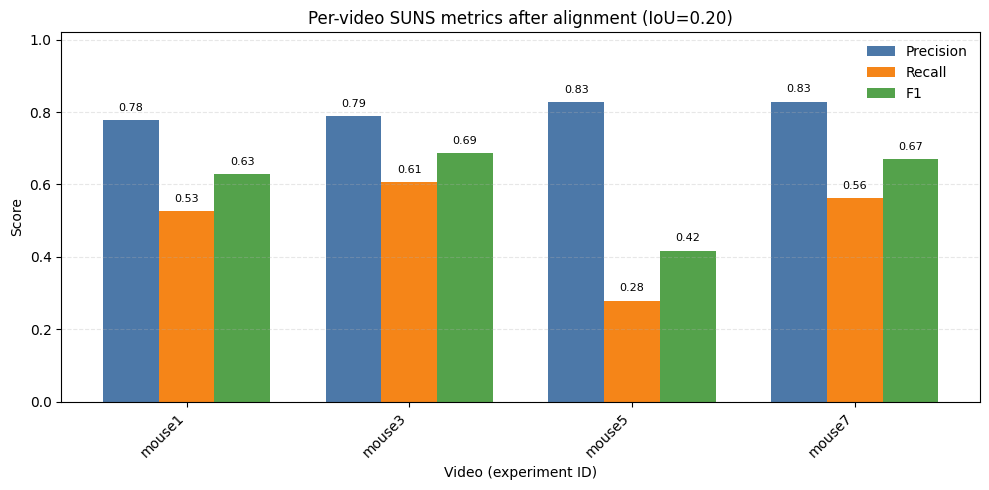

In [21]:
# --- Per-video SUNS metrics after alignment (mouse names on x-axis) ---
from suns.PostProcessing.evaluate import GetPerformance_Jaccard_2
from scipy import sparse
import numpy as np
import os

# IoU evaluation threshold (edit as desired)
iou_eval = 0.2 # e.g., set to 0.20 or 0.30 to match your analysis

exp_ids = list(list_Exp_ID)  # e.g., ['mouse1','mouse3','mouse5',...]

precision_list, recall_list, f1_list = [], [], []

for eid in exp_ids:
    # --- paths ---
    raw_h5_e   = os.path.join(dir_video, f'{eid}.h5')
    gt_sparse_e = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{eid}_sparse.mat')
    pred_mat_e  = os.path.join(dir_output, f'Output_Masks_{eid}.mat')

    # --- dims & max projection for alignment target ---
    # prefer network_input grid if available
    h5_net_in_e = os.path.join(dir_net_in, f'{eid}.h5')
    if os.path.exists(h5_net_in_e):
        with h5py.File(h5_net_in_e, 'r') as f:
            net_in_e = np.array(f['network_input'])
        Lx_net_e, Ly_net_e = net_in_e.shape[1:]
        max_img_net_e = net_in_e.max(axis=0).astype(np.float32)
        vmin_, vmax_ = float(max_img_net_e.min()), float(max_img_net_e.max())
        if vmax_ > vmin_:
            max_img_net_e = (max_img_net_e - vmin_) / (vmax_ - vmin_)
    else:
        # fall back to raw movie for target grid
        with h5py.File(raw_h5_e, 'r') as f:
            dset_name_e = find_dataset(f)
            Lx_net_e, Ly_net_e = f[dset_name_e].shape[1:3]
            # build max projection without loading entire movie into RAM
            max_img_net_e = compute_max_projection_from_h5(raw_h5_e)

    # raw dims (fast)
    with h5py.File(raw_h5_e, 'r') as f:
        dset_name_e = find_dataset(f)
        Lx_raw_e, Ly_raw_e = f[dset_name_e].shape[1:3]

    # --- load raw GT and predicted masks ---
    if os.path.exists(gt_sparse_e):
        gt_raw_e = load_gt_sparse_masks(gt_sparse_e, (Lx_raw_e, Ly_raw_e))
    else:
        gt_raw_e = np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)

    if os.path.exists(pred_mat_e):
        # initial load (shape may be raw or net)
        pred_e = load_pred_masks_from_mat(pred_mat_e, (Lx_raw_e, Ly_raw_e))
    else:
        pred_e = np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)

    # --- align both stacks to the target (network_input) grid ---
    _, _, _, _, gt_aligned_e = _best_transform_for_masks(gt_raw_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)

    if pred_e.shape[1:] == (Lx_raw_e, Ly_raw_e):
        _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
    else:
        _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, pred_e.shape[1:], (Lx_net_e, Ly_net_e), max_img_net_e)

    # --- SUNS evaluation ---
    GTMasks_csr_e  = sparse.csr_matrix(gt_aligned_e.reshape(gt_aligned_e.shape[0], -1).astype(np.uint32))
    PredMasks_csr_e = sparse.csr_matrix(pred_aligned_e.reshape(pred_aligned_e.shape[0], -1).astype(np.uint32))
    ThreshJ = 1.0 - float(iou_eval)
    R, P, F1 = GetPerformance_Jaccard_2(GTMasks_csr_e, PredMasks_csr_e, ThreshJ=ThreshJ)

    precision_list.append(float(P))
    recall_list.append(float(R))
    f1_list.append(float(F1))

    print(f"{eid}: IoU={iou_eval:.2f}  P={P:.3f}  R={R:.3f}  F1={F1:.3f}")

# --- plot grouped bars: one group per video name ---
import matplotlib.pyplot as plt
x = np.arange(len(exp_ids)); w = 0.25
plt.figure(figsize=(max(10, 1.8*len(exp_ids)), 5))
plt.bar(x - w, precision_list, width=w, label='Precision', color='#4C78A8')
plt.bar(x,      recall_list,    width=w, label='Recall',    color='#F58518')
plt.bar(x + w,  f1_list,        width=w, label='F1',        color='#54A24B')
plt.xticks(x, exp_ids, rotation=45, ha='right')
plt.ylim(0, 1.02)
plt.xlabel('Video (experiment ID)')
plt.ylabel('Score')
plt.title(f'Per-video SUNS metrics after alignment (IoU={iou_eval:.2f})')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=False)

# annotate values on bars
for i in range(len(exp_ids)):
    for j, v in enumerate([precision_list[i], recall_list[i], f1_list[i]]):
        xpos = x[i] + (j-1)*w
        plt.text(xpos, min(0.98, v + 0.02), f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



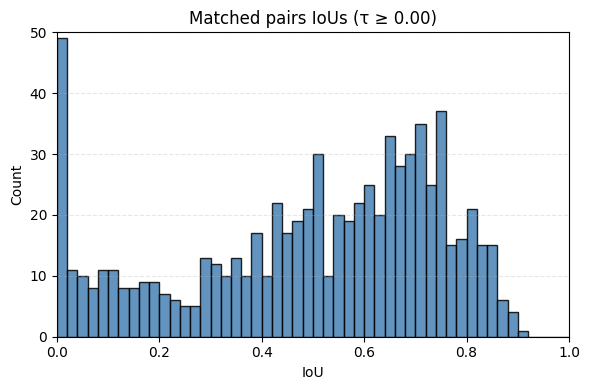

In [22]:
# --- Histogram of matched-pair IoU (0 → 1) ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

# Threshold used for matching (default 0.0 if not set earlier)
tau_local = float(tau) if 'tau' in globals() else 0.0

# Obtain matched IoUs. Use precomputed if available; otherwise compute matching now.
if 'matched_iou' in globals():
    mi = matched_iou.astype(np.float32)
else:
    # Build pairwise IoU
    if 'IoU' in globals():
        I = IoU.astype(np.float32)
    else:
        if 'gt_masks' in globals() and 'pred_masks' in globals() and gt_masks.size and pred_masks.size:
            A = gt_masks.reshape(gt_masks.shape[0], -1).astype(np.uint8)
            B = pred_masks.reshape(pred_masks.shape[0], -1).astype(np.uint8)
            inter = A @ B.T
            a_sum = A.sum(axis=1, keepdims=True)
            b_sum = B.sum(axis=1, keepdims=True).T
            union = a_sum + b_sum - inter
            I = np.zeros_like(inter, dtype=np.float32)
            valid = union > 0
            I[valid] = inter[valid] / union[valid]
        else:
            I = np.zeros((0, 0), dtype=np.float32)
    # Match with threshold tau_local
    if I.size:
        cost = 1.0 - I
        cost[I < tau_local] = 1e6
        ri, ci = linear_sum_assignment(cost)
        m = I[ri, ci]
        mi = m[m >= tau_local].astype(np.float32)
    else:
        mi = np.array([], dtype=np.float32)

bins = np.linspace(0.0, 1.0, 51)  # 50 uniform bins from 0 to 1

plt.figure(figsize=(6, 4))
plt.hist(mi, bins=bins, color='steelblue', alpha=0.85, edgecolor='k')
plt.xlabel('IoU')
plt.ylabel('Count')
plt.title(f'Matched pairs IoUs (τ ≥ {tau_local:.2f})')
plt.xlim(0, 1)
plt.ylim(0, 50)  # Fix y-axis to 0–40 for comparability
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Matched pairs (IoU≥0.0): 748
IoU percentiles: [0.         0.33333334 0.55198148 0.70326968 0.82681994]


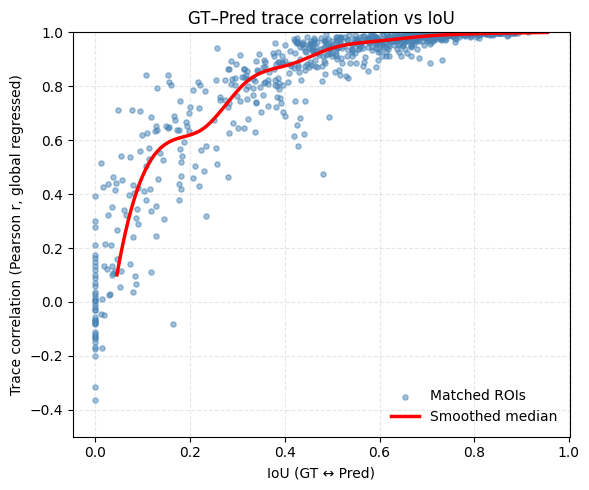

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

# -------- helpers --------
def ensure_stack_first(masks):
    # Accept (N,Y,X) or (Y,X,N); return (N,Y,X)
    if masks.ndim != 3:
        raise ValueError("masks must be 3D")
    if masks.shape[0] in (masks.shape[1], masks.shape[2]) and masks.shape[0] != masks.shape[-1]:
        # likely (Y,X,N)
        return np.moveaxis(masks, -1, 0)
    return masks

def pairwise_iou(A_bool, B_bool):
    A_bool = ensure_stack_first(A_bool).astype(bool)
    B_bool = ensure_stack_first(B_bool).astype(bool)
    Na, H, W = A_bool.shape
    Nb = B_bool.shape[0]
    A2 = A_bool.reshape(Na, -1).astype(np.uint8)
    B2 = B_bool.reshape(Nb, -1).astype(np.uint8)
    inter = A2 @ B2.T                           # (Na,Nb) pixel intersections
    a_sum = A2.sum(axis=1, keepdims=True)       # (Na,1)
    b_sum = B2.sum(axis=1, keepdims=True).T     # (1,Nb)
    union = a_sum + b_sum - inter
    I = np.zeros_like(inter, dtype=np.float32)
    valid = union > 0
    I[valid] = inter[valid] / union[valid]
    return I

def extract_mean_traces(video_T_y_x, masks_bool):
    masks_bool = ensure_stack_first(masks_bool).astype(bool)
    T = video_T_y_x.shape[0]
    traces = np.zeros((masks_bool.shape[0], T), dtype=np.float32)
    for i, m in enumerate(masks_bool):
        if m.any():
            traces[i] = video_T_y_x[:, m].mean(axis=1)
    return traces

def zscore_rows(X, eps=1e-8):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sd

def regress_out_global(traces, global_trace):
    # remove projection onto the global signal: r = t - ((t·g)/(g·g)) g
    g = (global_trace - global_trace.mean()) / (global_trace.std() + 1e-8)
    gg = np.dot(g, g) + 1e-8
    proj = (traces @ g[None, :].T) / gg           # (N,1)
    return traces - proj * g[None, :]

# -------- compute IoU & match with threshold --------
IoU = pairwise_iou(gt_masks, pred_masks)

tau = 0.0 # <-- set acceptance threshold here
cost = 1.0 - IoU
cost[IoU < tau] = 1e6                            # forbid low-overlap pairs

row_ind, col_ind = linear_sum_assignment(cost)
matched_iou = IoU[row_ind, col_ind]
keep = matched_iou >= tau
row_ind, col_ind, matched_iou = row_ind[keep], col_ind[keep], matched_iou[keep]

print(f"Matched pairs (IoU≥{tau}): {len(matched_iou)}")
print("IoU percentiles:", np.percentile(matched_iou, [5,25,50,75,95]))

# -------- traces, z-score, and global/neuropil removal --------
# network_input : (T,Y,X) – same movie used for both GT and Pred
gt_tr  = extract_mean_traces(network_input, gt_masks)   # (N_gt, T)
pr_tr  = extract_mean_traces(network_input, pred_masks) # (N_pr, T)

# remove FOV global signal (crude neuropil/global correction)
gtrace = network_input.mean(axis=(1,2)).astype(np.float32)  # (T,)
gt_tr = regress_out_global(gt_tr, gtrace)
pr_tr = regress_out_global(pr_tr, gtrace)

# z-score rows
gt_z = zscore_rows(gt_tr)
pr_z = zscore_rows(pr_tr)

# -------- correlations per matched pair --------
corrs = np.empty_like(matched_iou, dtype=np.float32)
for k, (gi, pi) in enumerate(zip(row_ind, col_ind)):
    t1, t2 = gt_z[gi], pr_z[pi]
    T_use = min(t1.size, t2.size)
    r = np.corrcoef(t1[:T_use], t2[:T_use])[0, 1]
    corrs[k] = r

# -------- plot: scatter + binned trend --------
# -------- plot: scatter + smooth red trend line --------
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

x, y = matched_iou, corrs

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=14, alpha=0.5, color='steelblue', label='Matched ROIs')

# compute median per bin (for a stable baseline)
bins = np.linspace(tau, 1.0, 12)
centers = 0.5*(bins[:-1] + bins[1:])
med = [np.median(y[(x>=bins[i]) & (x<bins[i+1])]) if np.any((x>=bins[i]) & (x<bins[i+1])) else np.nan
       for i in range(len(bins)-1)]
centers, med = np.array(centers), np.array(med)

# smooth with a spline (cubic)
mask = np.isfinite(med)
if np.sum(mask) >= 4:
    spline = make_interp_spline(centers[mask], med[mask], k=3)
    x_smooth = np.linspace(centers[mask].min(), centers[mask].max(), 300)
    y_smooth = spline(x_smooth)
    plt.plot(x_smooth, y_smooth, color='red', lw=2.5, label='Smoothed median')
else:
    plt.plot(centers, med, color='red', lw=2.5, label='Median (unsmoothed)') # change color to red

plt.xlabel('IoU (GT ↔ Pred)')
plt.ylabel('Trace correlation (Pearson r, global regressed)')
#plt.title('GT–Pred trace correlation vs IoU (τ = %.2f)' % tau)
plt.title('GT–Pred trace correlation vs IoU')
plt.grid(True, linestyle='--', alpha=0.3)
plt.ylim(-0.5, 1.0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# The plot compares spatial overlap (IoU) with temporal similarity 
# (correlation of calcium traces) between matched ROIs from  
# two segmentation methods.
# Each blue dot is one matched neuron pair (GT - Pred).


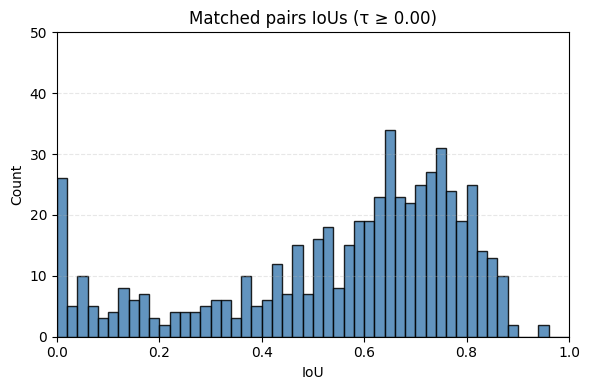

In [10]:
# --- Histogram of matched-pair IoU (0 → 1) ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

# Threshold used for matching (default 0.0 if not set earlier)
tau_local = float(tau) if 'tau' in globals() else 0.0

# Obtain matched IoUs. Use precomputed if available; otherwise compute matching now.
if 'matched_iou' in globals():
    mi = matched_iou.astype(np.float32)
else:
    # Build pairwise IoU
    if 'IoU' in globals():
        I = IoU.astype(np.float32)
    else:
        if 'gt_masks' in globals() and 'pred_masks' in globals() and gt_masks.size and pred_masks.size:
            A = gt_masks.reshape(gt_masks.shape[0], -1).astype(np.uint8)
            B = pred_masks.reshape(pred_masks.shape[0], -1).astype(np.uint8)
            inter = A @ B.T
            a_sum = A.sum(axis=1, keepdims=True)
            b_sum = B.sum(axis=1, keepdims=True).T
            union = a_sum + b_sum - inter
            I = np.zeros_like(inter, dtype=np.float32)
            valid = union > 0
            I[valid] = inter[valid] / union[valid]
        else:
            I = np.zeros((0, 0), dtype=np.float32)
    # Match with threshold tau_local
    if I.size:
        cost = 1.0 - I
        cost[I < tau_local] = 1e6
        ri, ci = linear_sum_assignment(cost)
        m = I[ri, ci]
        mi = m[m >= tau_local].astype(np.float32)
    else:
        mi = np.array([], dtype=np.float32)

bins = np.linspace(0.0, 1.0, 51)  # 50 uniform bins from 0 to 1

plt.figure(figsize=(6, 4))
plt.hist(mi, bins=bins, color='steelblue', alpha=0.85, edgecolor='k')
plt.xlabel('IoU')
plt.ylabel('Count')
plt.title(f'Matched pairs IoUs (τ ≥ {tau_local:.2f})')
plt.xlim(0, 1)
plt.ylim(0, 50)  # Fix y-axis to 0–40 for comparability
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


**Consume ratio (what it is and where it is set)**

- The post-processing merges masks that have a high one-sided overlap called "consume ratio": intersection/area of the source mask. In code, consume is computed as intersection divided by the area of mask i:

```249:256:suns/PostProcessing/combine.py
area_i = tempmasks.dot(tempmasks.T).toarray()
area = area_i.diagonal()
area_i = area_i - np.diag(area)
a2 = np.expand_dims(area, axis=0).repeat(N, axis=0)
consume = area_i / a2
```

- The threshold used for this merge is `Params['thresh_consume']` when running the complete post-processing:

```36:41:suns/PostProcessing/complete_post.py
Params['thresh_COM']: Threshold of COM distance (unit: pixels) used for the second COM-based merging. 
Params['thresh_IOU']: Threshold of IOU used for merging neurons.
Params['thresh_consume']: Threshold of consume ratio used for merging neurons.
Params['cons']: Minimum number of consecutive frames that a neuron should be active for.
```

- When only optimizing a subset of parameters, the code sets a default relation between consume-threshold and IoU-threshold as:

```164:168:suns/PostProcessing/complete_post.py
thresh_IOU = Params['thresh_IOU']
thresh_consume = (1+thresh_IOU)/2
list_cons = Params['list_cons']
```

In other words, if IoU threshold is 0.3, the default consume threshold becomes 0.65; if IoU is 0.2, consume becomes 0.60. Below we compute metrics using consume ratio instead of IoU.


t=0.2: frac_pred_above = 0.86
t=0.3: frac_pred_above = 0.83
t=0.5: frac_pred_above = 0.69


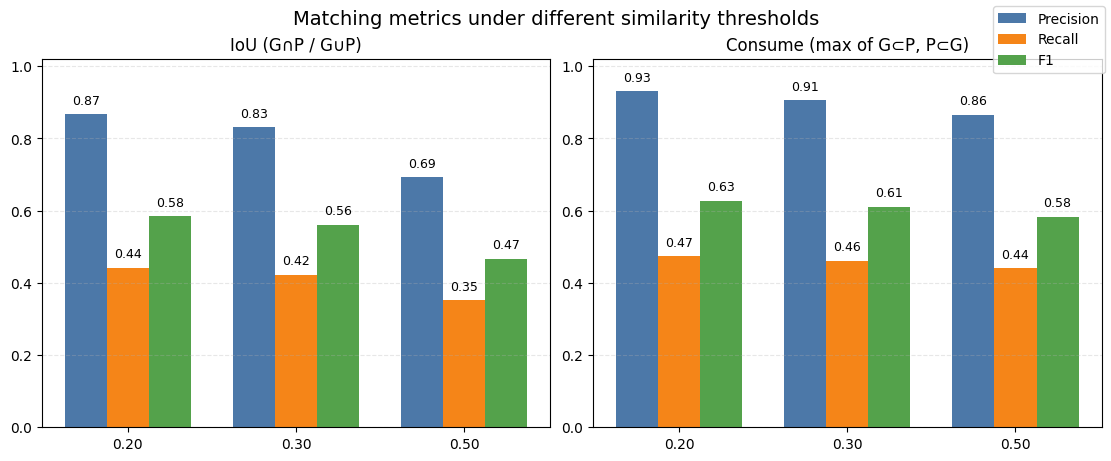

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

# ------------------------- INPUTS -------------------------
# Expected inputs already in memory:
#   gt_masks   : (N_gt, H, W) boolean
#   pred_masks : (N_pr, H, W) boolean
#
# If your arrays are not boolean or not (N,H,W), adapt below or cast:
# gt_masks = gt_masks.astype(bool)
# pred_masks = pred_masks.astype(bool)
# ----------------------------------------------------------

def ensure_stack_first(X):
    """Return masks as (N,H,W). Accepts (N,H,W) or (H,W,N)."""
    X = np.asarray(X)
    if X.ndim != 3:
        raise ValueError(f"Expected 3D array for masks, got shape {X.shape}")
    # If first dim is small and last dim is large, assume (H,W,N)
    if X.shape[0] <= 8 and X.shape[-1] > 8:
        X = np.transpose(X, (2,0,1))
    return X

def pairwise_intersection_and_areas(A_bool, B_bool):
    A = ensure_stack_first(A_bool).astype(bool).reshape(A_bool.shape[0], -1).astype(np.uint8)
    B = ensure_stack_first(B_bool).astype(bool).reshape(B_bool.shape[0], -1).astype(np.uint8)
    inter = A @ B.T                        # (Na, Nb) intersection areas
    area_A = A.sum(axis=1).astype(np.float32)  # (Na,)
    area_B = B.sum(axis=1).astype(np.float32)  # (Nb,)
    return inter.astype(np.float32), area_A, area_B

def pairwise_overlap_metrics(gt_masks_bool, pr_masks_bool):
    """Return dict of IoU, consume_max, consume_avg, dice pairwise matrices (n_gt x n_pr)."""
    inter, area_g, area_p = pairwise_intersection_and_areas(gt_masks_bool, pr_masks_bool)
    # avoid zero division
    area_g = np.maximum(area_g, 1.0)
    area_p = np.maximum(area_p, 1.0)
    # metrics
    iou = inter / (area_g[:, None] + area_p[None, :] - inter + 1e-8)
    cons_g = inter / area_g[:, None]
    cons_p = inter / area_p[None, :]
    consume_max = np.maximum(cons_g, cons_p)
    consume_avg = 0.5 * (cons_g + cons_p)
    dice = 2.0 * inter / (area_g[:, None] + area_p[None, :] + 1e-8)
    return dict(iou=iou, consume_max=consume_max, consume_avg=consume_avg, dice=dice)

def match_metrics_from_similarity(S, thr):
    """
    Given a similarity matrix S (n_gt x n_pr) and threshold thr,
    do 1-1 matching with Hungarian assignment on cost = 1 - S (masking pairs < thr),
    then compute P/R/F1.
    """
    if S.size == 0:
        return dict(tp=0, fp=0, fn=0, precision=0.0, recall=0.0, f1=0.0)

    n_gt, n_pr = S.shape
    cost = 1.0 - S.copy()
    cost[S < thr] = 1e6  # disallow pairs below threshold
    gi, pi = linear_sum_assignment(cost)
    matched = S[gi, pi] >= thr
    tp = int(matched.sum())
    fp = int(n_pr - tp)
    fn = int(n_gt - tp)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    return dict(tp=tp, fp=fp, fn=fn, precision=precision, recall=recall, f1=f1)

def plot_metric_panel(ax, name, S, thresholds, colors=None):
    """Grouped bar chart of P/R/F1 for a set of thresholds on a given similarity matrix S."""
    if colors is None:
        colors = dict(Precision='#4C78A8', Recall='#F58518', F1='#54A24B')

    metrics = {'Precision': [], 'Recall': [], 'F1': []}
    for thr in thresholds:
        m = match_metrics_from_similarity(S, thr)
        metrics['Precision'].append(m['precision'])
        metrics['Recall'].append(m['recall'])
        metrics['F1'].append(m['f1'])

    x = np.arange(len(thresholds)); w = 0.25
    ax.bar(x - w, metrics['Precision'], width=w, label='Precision', color=colors['Precision'])
    ax.bar(x,      metrics['Recall'],    width=w, label='Recall',    color=colors['Recall'])
    ax.bar(x + w,  metrics['F1'],        width=w, label='F1',        color=colors['F1'])
    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.2f}" for t in thresholds])
    ax.set_ylim(0, 1.02)
    ax.set_title(name)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    # annotate bars
    for i in range(len(thresholds)):
        for j, key in enumerate(['Precision', 'Recall', 'F1']):
            val = metrics[key][i]
            xpos = x[i] + (j-1)*w
            ax.text(xpos, min(val + 0.02, 1.02), f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# -------- compute matrices --------
gt_masks_bool   = gt_masks.astype(bool)
pred_masks_bool = pred_masks.astype(bool)
M = pairwise_overlap_metrics(gt_masks_bool, pred_masks_bool)

# -------- thresholds per metric (edit as you like) --------
thr_iou   = [0.20, 0.30, 0.50]
thr_cmax  = [0.20, 0.30, 0.50]   # consume_max (SUNS often uses (1+IoU)/2; IoU=0.5 -> 0.75)
thr_cavg  = [0.20, 0.30, 0.50]   # consume_avg (softer aggregation)
thr_dice  = [0.20, 0.30, 0.50]

# -------- plot 1x2 panels (IoU and Consume) --------
for t in [0.2, 0.3, 0.5]:
    print(f"t={t}: frac_pred_above = {(matched_iou >= t).mean():.2f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

plot_metric_panel(axes[0], 'IoU (G∩P / G∪P)',           M['iou'],         thr_iou)
plot_metric_panel(axes[1], 'Consume (max of G⊂P, P⊂G)', M['consume_max'], thr_cmax)

# single legend at top-right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

fig.suptitle('Matching metrics under different similarity thresholds', fontsize=14)
plt.show()


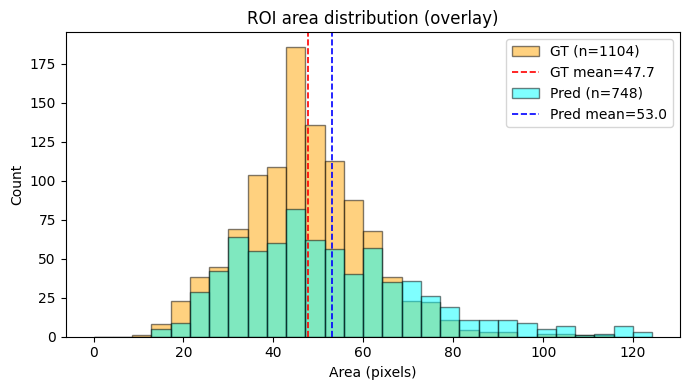

In [24]:
# --- ROI Area distributions (overlay on same axes) ---
# Compute per-ROI areas in pixels
areas_gt = gt_masks.reshape(gt_masks.shape[0], -1).sum(axis=1) if gt_masks.size else np.array([])
areas_pr = pred_masks.reshape(pred_masks.shape[0], -1).sum(axis=1) if pred_masks.size else np.array([])

# Common bins
all_areas = np.concatenate([areas_gt, areas_pr]) if areas_gt.size and areas_pr.size else (areas_gt if areas_gt.size else areas_pr)
if all_areas.size:
    hi = np.percentile(all_areas, 99.5)
    bins = np.linspace(0, hi, 30)
else:
    bins = 30

fig, ax = plt.subplots(figsize=(7, 4))

if areas_gt.size:
    ax.hist(areas_gt, bins=bins, color='orange', alpha=0.5, edgecolor='k', label=f'GT (n={len(areas_gt)})')
    mean_gt = float(np.mean(areas_gt))
    ax.axvline(mean_gt, color='red', linestyle='--', linewidth=1.2, label=f'GT mean={mean_gt:.1f}')

if areas_pr.size:
    ax.hist(areas_pr, bins=bins, color='cyan', alpha=0.5, edgecolor='k', label=f'Pred (n={len(areas_pr)})')
    mean_pr = float(np.mean(areas_pr))
    ax.axvline(mean_pr, color='blue', linestyle='--', linewidth=1.2, label=f'Pred mean={mean_pr:.1f}')

ax.set_title('ROI area distribution (overlay)')
ax.set_xlabel('Area (pixels)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment

# ---------- utilities ----------
def ensure_stack_first(masks):
    if masks.ndim != 3:
        raise ValueError("masks must be 3D")
    if masks.shape[0] in (masks.shape[1], masks.shape[2]) and masks.shape[0] != masks.shape[-1]:
        return np.moveaxis(masks, -1, 0)
    return masks

def pairwise_iou(A_bool, B_bool):
    A_bool = ensure_stack_first(A_bool).astype(bool)
    B_bool = ensure_stack_first(B_bool).astype(bool)
    Na, H, W = A_bool.shape
    Nb = B_bool.shape[0]
    A2 = A_bool.reshape(Na, -1).astype(np.uint8)
    B2 = B_bool.reshape(Nb, -1).astype(np.uint8)
    inter = A2 @ B2.T
    a_sum = A2.sum(axis=1, keepdims=True)
    b_sum = B2.sum(axis=1, keepdims=True).T
    union = a_sum + b_sum - inter
    I = np.zeros_like(inter, dtype=np.float32)
    valid = union > 0
    I[valid] = inter[valid] / union[valid]
    return I

def roi_trace(video_TYX, mask_YX):
    if not mask_YX.any():
        return np.zeros(video_TYX.shape[0], dtype=np.float32)
    return video_TYX[:, mask_YX].mean(axis=1)

def zscore(x, eps=1e-8):
    return (x - x.mean()) / (x.std() + eps)

def regress_out_global(trace, g):
    g = (g - g.mean()) / (g.std() + 1e-8)
    gg = np.dot(g, g) + 1e-8
    return trace - (np.dot(trace, g) / gg) * g

def center_of_mass(mask):
    y, x = ndi.center_of_mass(mask.astype(float))
    if np.isnan(y):  # fallback
        H, W = mask.shape
        return H/2, W/2
    return y, x

def crop(arr_YX, cy, cx, half=28):
    H, W = arr_YX.shape
    y1, y2 = int(cy-half), int(cy+half+1)
    x1, x2 = int(cx-half), int(cx+half+1)
    py1, py2 = max(0,-y1), max(0,y2-H)
    px1, px2 = max(0,-x1), max(0,x2-W)
    y1c, y2c = max(0,y1), min(H,y2)
    x1c, x2c = max(0,x1), min(W,x2)
    patch = arr_YX[y1c:y2c, x1c:x2c]
    if py1 or py2 or px1 or px2:
        patch = np.pad(patch, ((py1,py2),(px1,px2)), mode='edge')
    return patch

# ---------- main: overlay masks + overlapped traces ----------
def show_pairs_overlay_and_traces(
    video_TYX, gt_masks, pred_masks,
    pairs=None, iou_threshold=0.3, n_pairs=6, half=28,
    global_regress=True, zscore_tr=True, sort_by="IoU"
):
    """
    For each pair: left subplot = max-projection patch with GT (orange) + Pred (cyan) contours.
                   right subplot = overlapped traces (GT vs Pred) on same axes.
    Titles show IoU and Pearson r.
    """
    gt_masks = ensure_stack_first(gt_masks).astype(bool)
    pred_masks = ensure_stack_first(pred_masks).astype(bool)

    # match if not provided
    if pairs is None:
        I = pairwise_iou(gt_masks, pred_masks)
        cost = 1.0 - I
        cost[I < iou_threshold] = 1e6
        gi, pi = linear_sum_assignment(cost)
        m_iou = I[gi, pi]
        keep = m_iou >= iou_threshold
        gi, pi, m_iou = gi[keep], pi[keep], m_iou[keep]
        pairs = list(zip(gi, pi))
        ious = m_iou
    else:
        # compute IoU for the provided pairs for sorting/annotation
        I = pairwise_iou(gt_masks, pred_masks)
        ious = np.array([I[g, p] for g, p in pairs])

    # pick subset
    if sort_by.lower() == "iou":
        order = np.argsort(ious)[::-1]
    else:
        order = np.arange(len(pairs))
    sel = order[:min(n_pairs, len(pairs))]
    pairs_sel = [pairs[i] for i in sel]
    ious_sel  = ious[sel]

    # global signal for optional regression
    g = video_TYX.mean(axis=(1,2)) if global_regress else None

    # figure
    n = len(pairs_sel)
    n_cols = 2
    n_rows = n
    fig = plt.figure(figsize=(8.8, 2.8*n_rows))

    maxproj = video_TYX.max(axis=0)
    vmin, vmax = np.percentile(maxproj, (1, 99))

    for row, ((gidx, pidx), iou_val) in enumerate(zip(pairs_sel, ious_sel), start=1):
        mgt = gt_masks[gidx]; mpr = pred_masks[pidx]

        # center crop around the average COM
        y1, x1 = center_of_mass(mgt); y2, x2 = center_of_mass(mpr)
        cy, cx = (y1+y2)/2, (x1+x2)/2
        patch = crop(maxproj, cy, cx, half=half)
        mgt_c = crop(mgt.astype(float), cy, cx, half=half) > 0.5
        mpr_c = crop(mpr.astype(float), cy, cx, half=half) > 0.5

        # traces
        t_gt = roi_trace(video_TYX, mgt)
        t_pr = roi_trace(video_TYX, mpr)
        if global_regress:
            t_gt = regress_out_global(t_gt, g)
            t_pr = regress_out_global(t_pr, g)
        if zscore_tr:
            t_gt = zscore(t_gt); t_pr = zscore(t_pr)

        # correlation
        r = np.corrcoef(t_gt, t_pr)[0,1]

        # --- left: image + both contours ---
        axL = plt.subplot(n_rows, n_cols, 2*row-1)
        axL.imshow(patch, cmap='gray', vmin=vmin, vmax=vmax)
        axL.contour(mgt_c, levels=[0.5], colors='#F39C12', linewidths=1.6, alpha=0.95, linestyles='-')   # GT: orange
        axL.contour(mpr_c, levels=[0.5], colors='#17A2B8', linewidths=1.6, alpha=0.95, linestyles='-')   # Pred: cyan
        axL.set_title(f"GT #{gidx} vs Pred #{pidx}\nIoU={iou_val:.2f}, r={r:.2f}")
        axL.axis('off')

        # --- right: overlapped traces ---
        axR = plt.subplot(n_rows, n_cols, 2*row)
        axR.plot(t_gt, label='GT', lw=0.8, color='#F39C12')
        axR.plot(t_pr, label='Pred', lw=0.8, color='#17A2B8', alpha=0.85)
        axR.set_xlabel("Frame")
        axR.set_ylabel("Fluorescence (z)" if zscore_tr else "Fluorescence (a.u.)")
        axR.grid(True, ls='--', alpha=0.3)
        axR.legend(frameon=False, loc='upper right')

    plt.tight_layout()
    plt.show()


Plotting with IoU threshold = 0.2


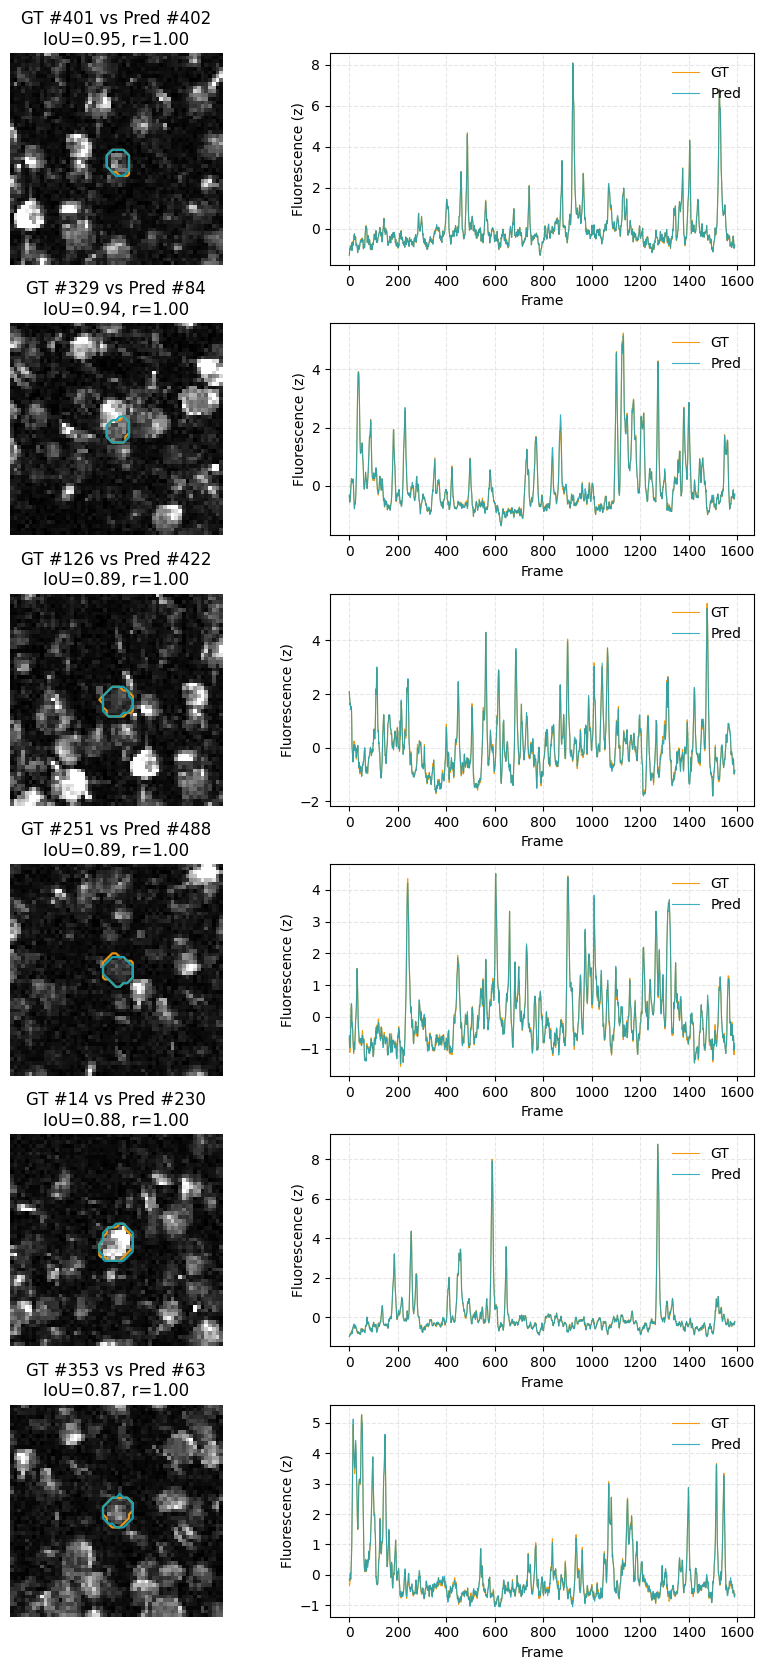

Plotting with IoU threshold = 0.3


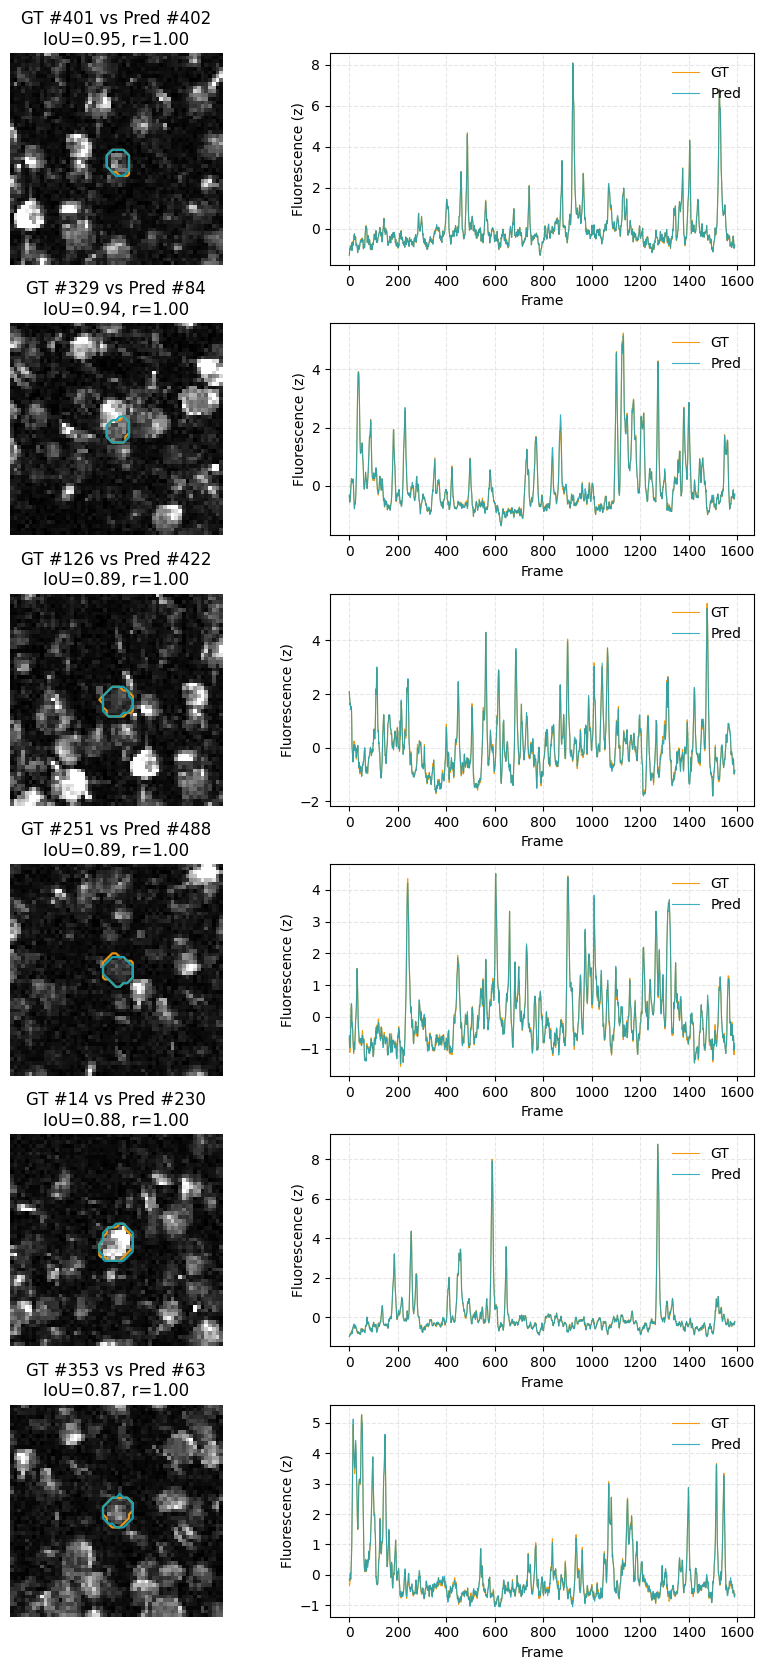

Plotting with IoU threshold = 0.5


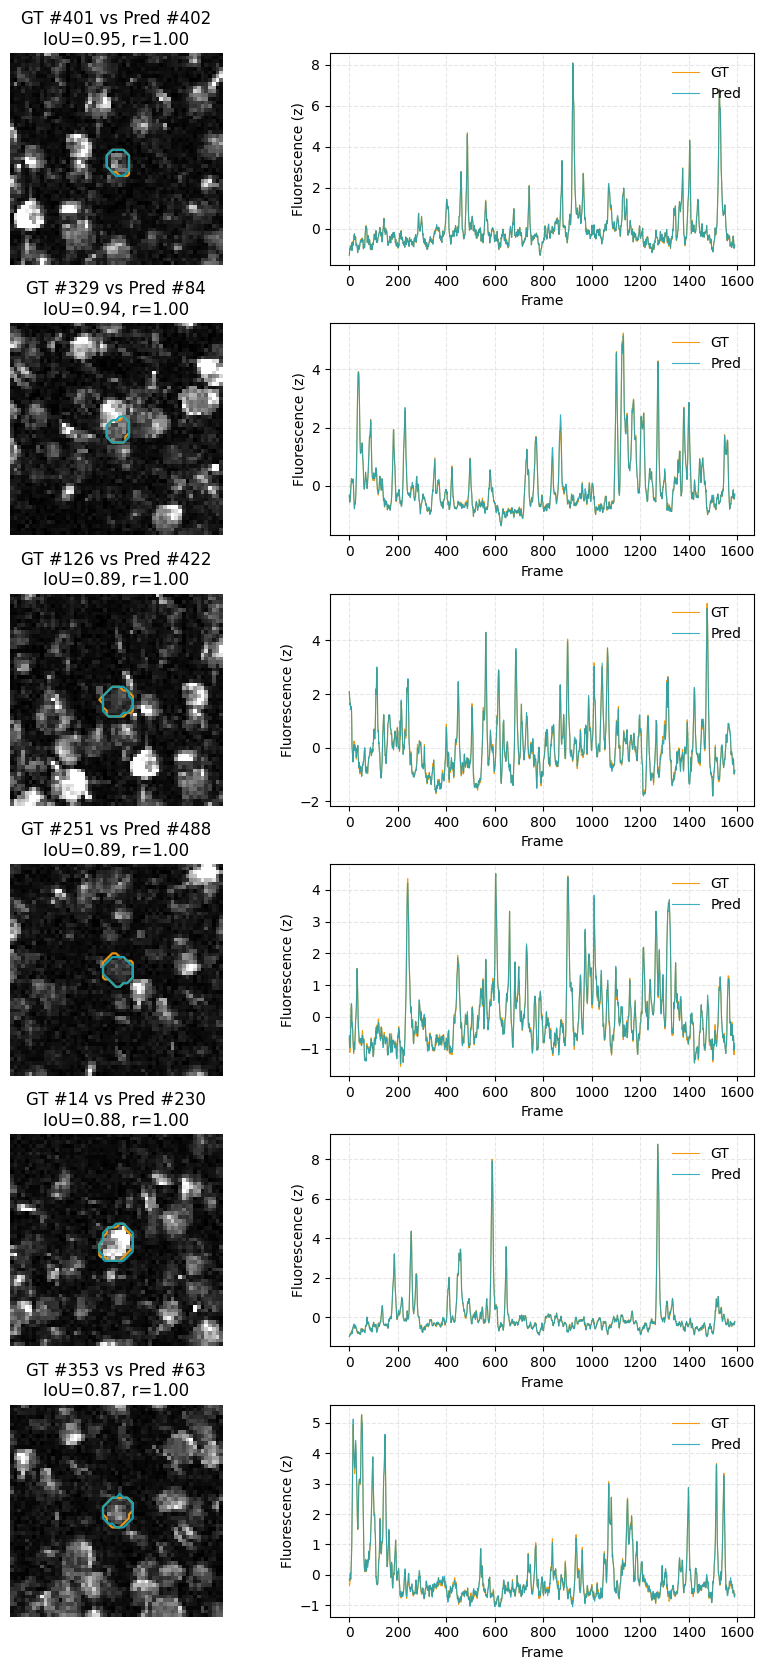

In [14]:
# # show 6 best-overlap pairs
# show_pairs_overlay_and_traces(
#     video_TYX=network_input, 
#     gt_masks=gt_masks,
#     pred_masks=pred_masks,
#     pairs=None,            # let it compute matches
#     iou_threshold=0.30,    # only confident matches
#     n_pairs=6,             # rows to display
#     half=30,               # crop radius
#     global_regress=True,
#     zscore_tr=True,
#     sort_by="IoU"
# )

for t in [0.2, 0.3, 0.5]:
    print(f"Plotting with IoU threshold = {t}")
    show_pairs_overlay_and_traces(
        video_TYX=network_input,
        gt_masks=gt_masks,
        pred_masks=pred_masks,
        iou_threshold=t,
        n_pairs=6,         # adjust if desired
        half=28,           # adjust crop size if desired
        global_regress=True,
        zscore_tr=True,
        sort_by="IoU"
    )

Target IoU = 0.20  ->  using GT #56, Pred #466 (IoU = 0.207)


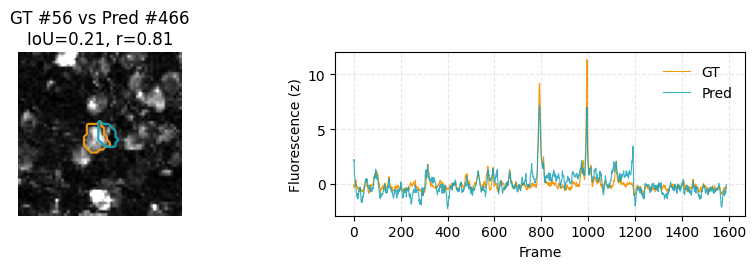

Target IoU = 0.30  ->  using GT #516, Pred #176 (IoU = 0.299)


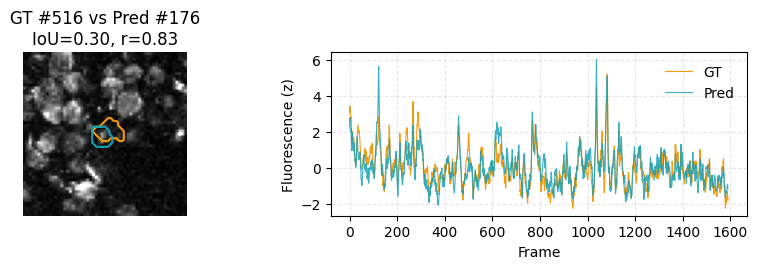

Target IoU = 0.50  ->  using GT #32, Pred #513 (IoU = 0.500)


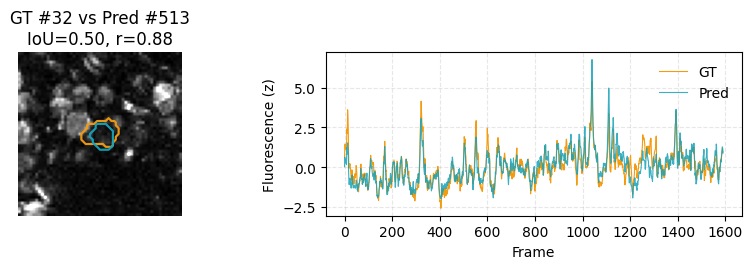

Target IoU = 0.80  ->  using GT #255, Pred #192 (IoU = 0.800)


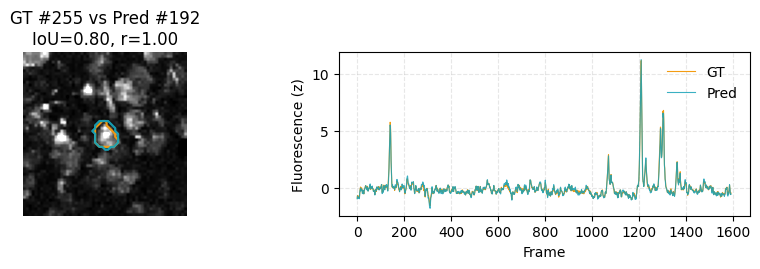

In [20]:
# --- compute matches once ---
I = pairwise_iou(gt_masks, pred_masks)       # (N_gt, N_pred)
cost = 1.0 - I
gi, pi = linear_sum_assignment(cost)         # matched indices
matched_ious = I[gi, pi]                     # IoU for each matched pair

def closest_pair_for_iou(target_iou, gi, pi, matched_ious):
    """Return GT index, Pred index and IoU of the pair closest to target_iou."""
    idx = np.argmin(np.abs(matched_ious - target_iou))
    return gi[idx], pi[idx], matched_ious[idx]

target_ious = [0.2, 0.3, 0.5, 0.8]

for tau in target_ious:
    g_idx, p_idx, real_iou = closest_pair_for_iou(tau, gi, pi, matched_ious)
    print(f"Target IoU = {tau:.2f}  ->  using GT #{g_idx}, Pred #{p_idx} (IoU = {real_iou:.3f})")

    # one example (one row: left = overlap, right = traces)
    show_pairs_overlay_and_traces(
        video_TYX=network_input,
        gt_masks=gt_masks,
        pred_masks=pred_masks,
        pairs=[(g_idx, p_idx)],  # <- explicit pair
        iou_threshold=0.0,       # ignored because 'pairs' is given
        n_pairs=1,
        half=28,
        global_regress=True,
        zscore_tr=True,
        sort_by="none"           # keep the order you pass in
    )


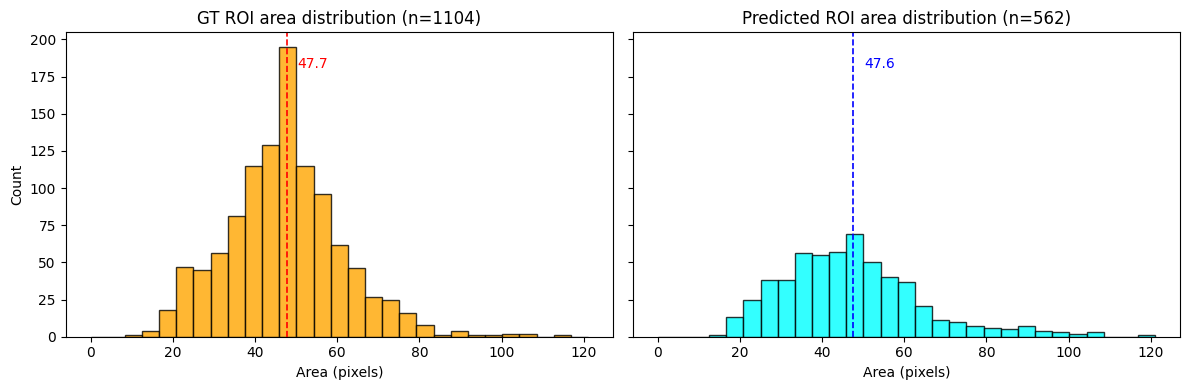

In [ ]:
# --- ROI Area distributions (bar graphs + mean markers) ---
# Compute per-ROI areas in pixels
areas_gt = gt_masks.reshape(gt_masks.shape[0], -1).sum(axis=1) if gt_masks.size else np.array([])
areas_pr = pred_masks.reshape(pred_masks.shape[0], -1).sum(axis=1) if pred_masks.size else np.array([])

# Use common bins for fair comparison
all_areas = np.concatenate([areas_gt, areas_pr]) if areas_gt.size and areas_pr.size else (areas_gt if areas_gt.size else areas_pr)
if all_areas.size:
    hi = np.percentile(all_areas, 99.5)
    bins = np.linspace(0, hi, 30)
else:
    bins = 30

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# GT bar graph + mean
ax[0].hist(areas_gt, bins=bins, color='orange', alpha=0.8, edgecolor='k')
ax[0].set_title(f'GT ROI area distribution (n={len(areas_gt)})')
ax[0].set_xlabel('Area (pixels)')
ax[0].set_ylabel('Count')
if areas_gt.size:
    mean_gt = float(np.mean(areas_gt))
    ax[0].axvline(mean_gt, color='red', linestyle='--', linewidth=1.2)
    ymax = ax[0].get_ylim()[1]
    xmin, xmax = ax[0].get_xlim()
    offset = 0.02 * (xmax - xmin)
    ax[0].text(min(mean_gt + offset, xmax), 0.92*ymax, f'{mean_gt:.1f}', color='red', ha='left', va='top')

# Pred bar graph + mean
ax[1].hist(areas_pr, bins=bins, color='cyan', alpha=0.8, edgecolor='k')
ax[1].set_title(f'Predicted ROI area distribution (n={len(areas_pr)})')
ax[1].set_xlabel('Area (pixels)')
if areas_pr.size:
    mean_pr = float(np.mean(areas_pr))
    ax[1].axvline(mean_pr, color='blue', linestyle='--', linewidth=1.2)
    ymax = ax[1].get_ylim()[1]
    xmin, xmax = ax[1].get_xlim()
    offset = 0.02 * (xmax - xmin)
    ax[1].text(min(mean_pr + offset, xmax), 0.92*ymax, f'{mean_pr:.1f}', color='blue', ha='left', va='top')

plt.tight_layout(); plt.show()


GT  mean circularity:  0.727 ± 0.142
Pred mean circularity: 0.849 ± 0.077


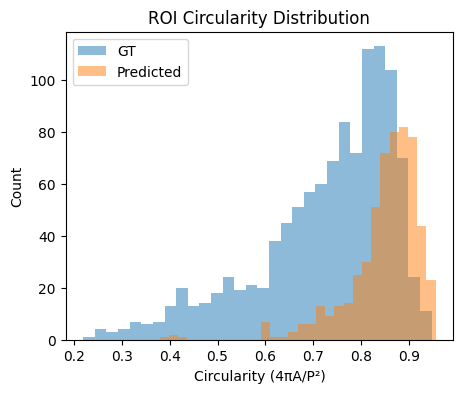

In [61]:
from skimage import measure

def compute_circularity(masks):
    """
    Compute circularity for each binary mask in the stack.
    Circularity = 4π * Area / (Perimeter²)
    Returns list of circularity values and perimeters.
    """
    circularities, perimeters, areas = [], [], []

    for i, mask in enumerate(masks):
        mask = mask.astype(bool)
        if not np.any(mask):
            circularities.append(np.nan)
            perimeters.append(0)
            areas.append(0)
            continue

        # Area = number of pixels
        area = np.sum(mask)
        areas.append(area)

        # Extract contours and measure perimeter in pixels
        contours = measure.find_contours(mask, 0.5)
        perim = 0.0
        for c in contours:
            diff = np.diff(c, axis=0)
            perim += np.sum(np.sqrt((diff ** 2).sum(axis=1)))
        perimeters.append(perim)

        # Circularity formula (avoid division by 0)
        circ = 4 * np.pi * area / (perim ** 2 + 1e-8)
        circularities.append(circ)

    return np.array(circularities), np.array(perimeters), np.array(areas)


# ---- Compute shape metrics for both GT and predictions ----
circ_gt, perim_gt, area_gt = compute_circularity(gt_masks)
circ_pr, perim_pr, area_pr = compute_circularity(pred_masks)

print(f"GT  mean circularity:  {np.nanmean(circ_gt):.3f} ± {np.nanstd(circ_gt):.3f}")
print(f"Pred mean circularity: {np.nanmean(circ_pr):.3f} ± {np.nanstd(circ_pr):.3f}")

# ---- Optional visualization ----
plt.figure(figsize=(5,4))
plt.hist(circ_gt, bins=30, alpha=0.5, label='GT')
plt.hist(circ_pr, bins=30, alpha=0.5, label='Predicted')
plt.xlabel('Circularity (4πA/P²)')
plt.ylabel('Count')
plt.legend()
plt.title('ROI Circularity Distribution')
plt.show()

# Each bar shows how many ROIs have a given circularity value. circularity= 4πA/P²: 1.0 means a perfect circle; lower values mean more elongated/irregular shapes.
# GT = 0.753, Pred = 0.841 mean the predicted ROIs are, on average, rounder and more uniform than the GT. The broader GT histogram indicates more shape 
# variety (irregular/merged cells).
# Any values slightly above 1 are due to pixel-grid/perimeter approximation; they’re harmless. If you want tighter estimates, compute perimeter with a sub‑pixel
#  method (e.g., skimage.measure.perimeter) or lightly smooth masks before measuring.

Online mat: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/output_masks_online/Output_Masks_mouse7.mat


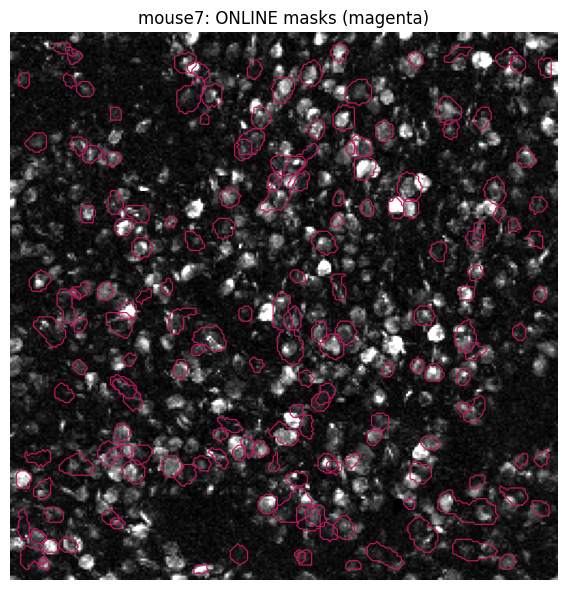

In [12]:
# --- Plot ONLINE masks (from output_masks_online) over max projection ---
import os, h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# Paths
online_dir = os.path.join(dir_parent, 'output_masks_online')
online_mat = os.path.join(online_dir, f'Output_Masks_{exp_id}.mat')
print('Online mat:', online_mat)

if not os.path.exists(online_mat):
    print('Online masks file not found. Run the online script or adjust exp_id/paths.')
else:
    # Determine target grid and max projection (prefer network_input if available)
    if 'network_input' in globals():
        Lx_net, Ly_net = network_input.shape[1:]
        max_img_net = network_input.max(axis=0).astype(np.float32)
        vmin_, vmax_ = float(max_img_net.min()), float(max_img_net.max())
        if vmax_ > vmin_:
            max_img_net = (max_img_net - vmin_) / (vmax_ - vmin_)
    else:
        raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
        with h5py.File(raw_h5, 'r') as f:
            dset_name = find_dataset(f)
            Lx_net, Ly_net = f[dset_name].shape[1:3]
        # Use previously computed max_img if available; otherwise compute quickly
        if 'max_img' in globals():
            max_img_net = max_img.astype(np.float32)
        else:
            max_img_net = compute_max_projection_from_h5(raw_h5)

    # Raw dims
    raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
    with h5py.File(raw_h5, 'r') as f:
        dset_name = find_dataset(f)
        Lx_raw, Ly_raw = f[dset_name].shape[1:3]

    # Load ONLINE masks (they may be in raw or net dims)
    online_masks = load_pred_masks_from_mat(online_mat, (Lx_raw, Ly_raw))

    # Align ONLINE masks to target grid
    if online_masks.shape[1:] == (Lx_raw, Ly_raw):
        _, _, _, _, online_aligned = _best_transform_for_masks(
            online_masks, (Lx_raw, Ly_raw), (Lx_net, Ly_net), max_img_net
        )
    else:
        _, _, _, _, online_aligned = _best_transform_for_masks(
            online_masks, online_masks.shape[1:], (Lx_net, Ly_net), max_img_net
        )

    # --- Plot overlay: ONLINE masks in magenta ---
    vmin, vmax = np.percentile(max_img_net, (1, 99))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(max_img_net, cmap='gray', vmin=vmin, vmax=vmax)

    for i in range(online_aligned.shape[0]):
        m = online_aligned[i]
        if m.any():
            for c in measure.find_contours(m.astype(float), 0.5):
                ax.plot(c[:, 1], c[:, 0], color='#C2185B', lw=0.9, alpha=0.95)

    ax.set_title(f"{exp_id}: ONLINE masks (magenta)")
    ax.axis('off')
    plt.tight_layout(); plt.show()



Saved: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/overlay_online_mouse1.png


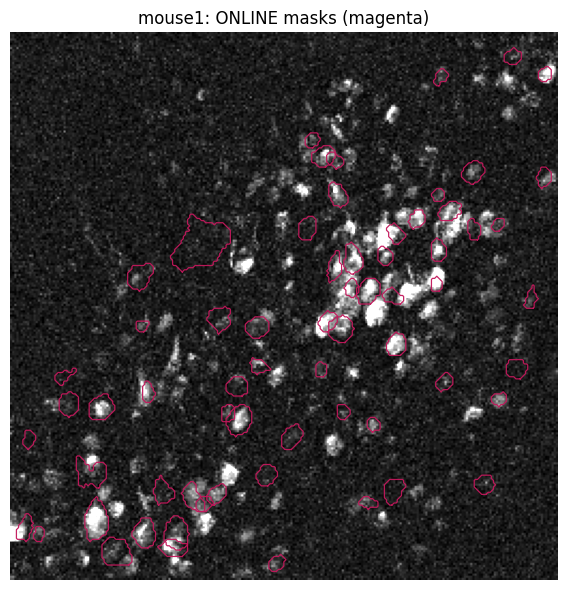

Saved: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/overlay_online_mouse3.png


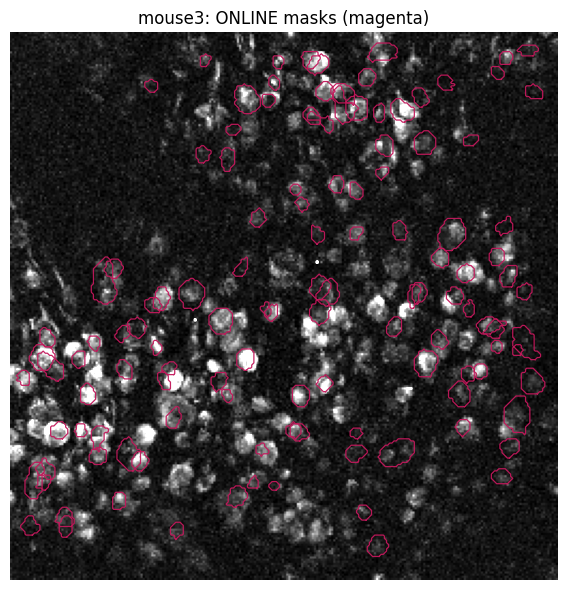

Saved: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/overlay_online_mouse5.png


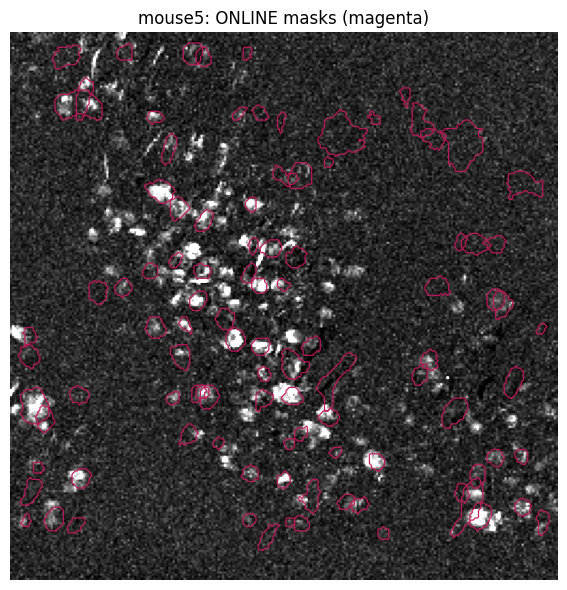

Saved: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/overlay_online_mouse6.png


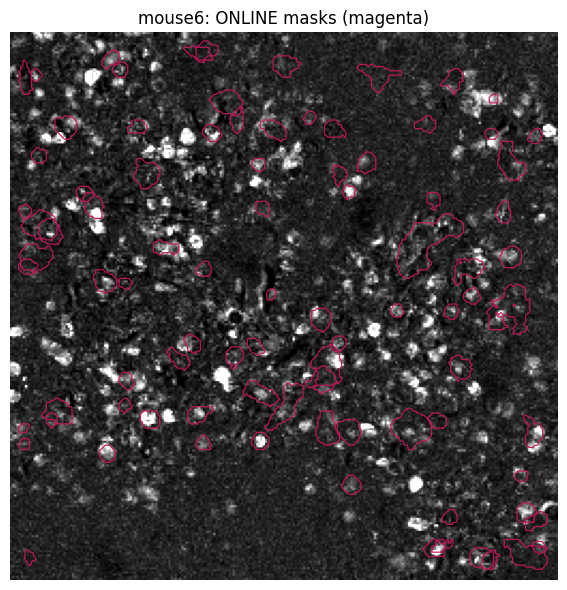

Saved: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/overlay_online_mouse7.png


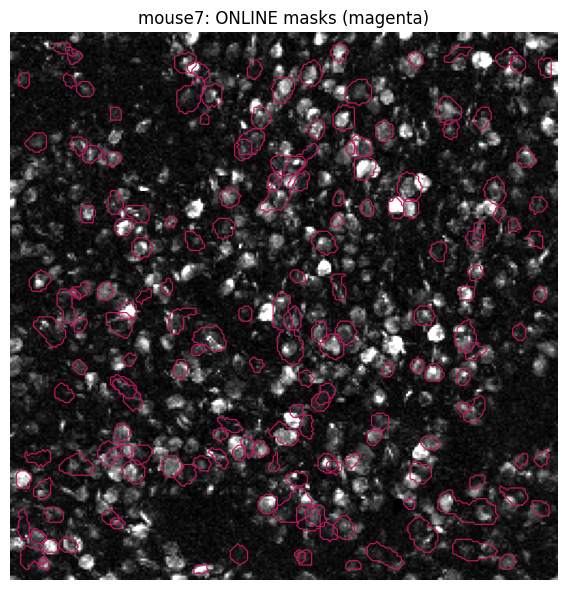

In [14]:
# --- Batch overlay: ONLINE masks for selected videos (mouse1,3,5,6,7,...) ---
import os, h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# Choose which experiment IDs to plot
exp_ids_batch = ['mouse1', 'mouse3', 'mouse5', 'mouse6', 'mouse7']  # edit as needed

online_dir = os.path.join(dir_parent, 'output_masks_online')

for eid in exp_ids_batch:
    online_mat_e = os.path.join(online_dir, f'Output_Masks_{eid}.mat')
    if not os.path.exists(online_mat_e):
        print(f'[skip] Online masks not found for {eid}: {online_mat_e}')
        continue

    # Target grid (prefer network_input if available)
    h5_net_in_e = os.path.join(dir_net_in, f'{eid}.h5')
    if os.path.exists(h5_net_in_e):
        with h5py.File(h5_net_in_e, 'r') as f:
            net_in_e = np.array(f['network_input'])
        Lx_net_e, Ly_net_e = net_in_e.shape[1:]
        max_img_net_e = net_in_e.max(axis=0).astype(np.float32)
        vmin_, vmax_ = float(max_img_net_e.min()), float(max_img_net_e.max())
        if vmax_ > vmin_:
            max_img_net_e = (max_img_net_e - vmin_) / (vmax_ - vmin_)
    else:
        raw_h5_e = os.path.join(dir_video, f'{eid}.h5')
        with h5py.File(raw_h5_e, 'r') as f:
            dset_name_e = find_dataset(f)
            Lx_net_e, Ly_net_e = f[dset_name_e].shape[1:3]
        max_img_net_e = compute_max_projection_from_h5(raw_h5_e)

    # Raw dims
    raw_h5_e = os.path.join(dir_video, f'{eid}.h5')
    with h5py.File(raw_h5_e, 'r') as f:
        dset_name_e = find_dataset(f)
        Lx_raw_e, Ly_raw_e = f[dset_name_e].shape[1:3]

    # Load online masks (raw or net dims) and align to target grid
    online_masks_e = load_pred_masks_from_mat(online_mat_e, (Lx_raw_e, Ly_raw_e))
    if online_masks_e.shape[1:] == (Lx_raw_e, Ly_raw_e):
        _, _, _, _, online_aligned_e = _best_transform_for_masks(
            online_masks_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e
        )
    else:
        _, _, _, _, online_aligned_e = _best_transform_for_masks(
            online_masks_e, online_masks_e.shape[1:], (Lx_net_e, Ly_net_e), max_img_net_e
        )

    # Plot overlay and save
    vmin, vmax = np.percentile(max_img_net_e, (1, 99))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(max_img_net_e, cmap='gray', vmin=vmin, vmax=vmax)

    for i in range(online_aligned_e.shape[0]):
        m = online_aligned_e[i]
        if m.any():
            for c in measure.find_contours(m.astype(float), 0.5):
                ax.plot(c[:, 1], c[:, 0], color='#C2185B', lw=0.9, alpha=0.95)

    ax.set_title(f"{eid}: ONLINE masks (magenta)")
    ax.axis('off')
    plt.tight_layout()

    out_png = os.path.join(dir_parent, f'overlay_online_{eid}.png')
    plt.savefig(out_png, dpi=200)
    print('Saved:', out_png)
    plt.show()
